# Olist Brazilian E-Commerce — Exploratory Data Analysis

**Dataset.** The Brazilian E-Commerce Public Dataset by Olist: nine related tables covering
~99,000 orders placed on the Olist marketplace between September 2016 and October 2018.
Olist connects small Brazilian sellers to major online marketplaces and handles logistics,
so an "order" may span multiple sellers and multiple shipments.

**What this analysis is for.** This is Phase 1: exploration and problem scoping. It does not
build models or make final recommendations. Its purpose is to establish what the data can
support, and to narrow a field of candidate analytics problems using evidence rather than
assumption. Two operational decisions motivate the work:

- **At checkout** — how many delivery days to quote the customer. Olist already issues a
  quote, so any replacement must beat the incumbent, not merely beat a naive baseline.
- **After delivery** — which orders to flag for customer-service follow-up before the review
  request is sent.

**Unit of analysis.** The primary analysis table is **one row per order**, keyed on
`order_id`. Because the source tables have different grains — an order has many items, may
have several payment records, and occasionally carries more than one review — each child
table is aggregated or deduplicated to order level *before* joining. Every join in this
notebook is validated: the row count must not change and the key must stay unique. A second
table, `item_level`, is kept at one row per order item for product and category analysis.

**Definitions used throughout.**

| Term | Definition |
|---|---|
| `delivery_days` | Days from purchase to delivery to the customer |
| `estimated_delivery_days` | Days from purchase to the date Olist quoted at checkout |
| `days_early` | Quoted date minus actual delivery date. **Positive = arrived early, negative = late** |
| `late_delivery_flag` | 1 if `days_early < 0`; `NaN` if the order was never delivered |
| `is_delivered_complete` | Status is `delivered` **and** a delivery timestamp exists — the population used for all delivery analysis |
| GMV | Gross merchandise value: the sum of item prices, excluding freight. Not Olist's revenue |
| R$ | Brazilian Real, the currency of all monetary figures |

**Method.** Findings are derived from the data programmatically rather than taken from
prior documentation. Where a planning assumption and the data disagreed, the data is
reported — several such cases are noted in the sections that follow.


## 1. Initial Setup with libraries and path

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
DATA_DIR = Path.cwd()
assert (DATA_DIR / "olist_orders_dataset.csv").exists(), f"CSVs not found in {DATA_DIR}"

### Loading the data

Here we will load the data by converting the date/time fields to datetime 



In [3]:
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv",
                    parse_dates=["order_purchase_timestamp", 
                                "order_approved_at", 
                                "order_delivered_carrier_date", 
                                "order_delivered_customer_date", 
                                "order_estimated_delivery_date"],)

order_items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv",
                    parse_dates=["shipping_limit_date"],)

reviews = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv",
                    parse_dates=["review_creation_date", 
                                 "review_answer_timestamp"],)

payments = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv",)
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv",)
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv",)
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv",)
geolocation = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv",)
category_translation = pd.read_csv(DATA_DIR / "product_category_name_translation.csv",)

TABLES = {
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "geolocation": geolocation,
    "category_translation": category_translation
}

for name,df in TABLES.items():
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")

orders: 99441 rows x 8 columns
order_items: 112650 rows x 7 columns
payments: 103886 rows x 5 columns
reviews: 99224 rows x 7 columns
customers: 99441 rows x 5 columns
sellers: 3095 rows x 4 columns
products: 32951 rows x 9 columns
geolocation: 1000163 rows x 5 columns
category_translation: 71 rows x 2 columns


In [4]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [5]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
first_order = orders.sort_values("order_purchase_timestamp").iloc[0]
last_order = orders.sort_values("order_purchase_timestamp").iloc[-1]
print(f"First order: {first_order['order_purchase_timestamp']}")
print(f"Last order: {last_order['order_purchase_timestamp']}")

First order: 2016-09-04 21:15:19
Last order: 2018-10-17 17:30:18


## 2. Dataset Overview

In [7]:
#Below done to identify potential colums for Primary key.

from itertools import combinations

def find_candidate_keys(df, max_key_size=2):
    candidates = []
    for size in range(1, max_key_size + 1):
        for cols in combinations(df.columns, size):
            cols = list(cols)
            n_nulls = df[cols].isna().any(axis=1).sum()
            n_dupes = df.duplicated(subset=cols).sum()
            if n_nulls == 0 and n_dupes == 0:
                candidates.append({
                    "columns":    tuple(cols),
                    "rows":       len(df),
                    "nulls":      n_nulls,
                    "duplicates": n_dupes,
                })
        if candidates:
            break
    return candidates

key_rows = []
for name, df in TABLES.items():
    keys = find_candidate_keys(df, max_key_size=2)
    if keys:
        for k in keys:
            key_rows.append({"table": name, **k})
    else:
        key_rows.append({
            "table": name, "columns": None, "rows": len(df),
            "nulls": None, "duplicates": df.duplicated().sum(),
        })

key_report = pd.DataFrame(key_rows)
key_report


,table,columns,rows,nulls,duplicates
0,orders,"(order_id,)",99441,0.0,0
1,orders,"(customer_id,)",99441,0.0,0
2,order_items,"(order_id, order_item_id)",112650,0.0,0
3,payments,"(order_id, payment_sequential)",103886,0.0,0
4,reviews,"(review_id, order_id)",99224,0.0,0
5,reviews,"(order_id, review_answer_timestamp)",99224,0.0,0
6,customers,"(customer_id,)",99441,0.0,0
7,sellers,"(seller_id,)",3095,0.0,0
8,products,"(product_id,)",32951,0.0,0
9,geolocation,None,1000163,NaN,261831


In [8]:
table_shared_rows = []

from collections import defaultdict

column_tables = defaultdict(list)
for name, df in TABLES.items():
    for col in df.columns:
        column_tables[col].append(name)

shared_columns = {col: tbls for col, tbls in column_tables.items() if len(tbls) > 1}

for col, tbls in sorted(shared_columns.items()):
    print(f"{col:35s} -> {tbls}")

for name, df in TABLES.items():
    for col in df.columns:
        if col in shared_columns:
            other_tables = [t for t in shared_columns[col] if t != name]
            table_shared_rows.append({
                "table":        name,
                "column":       col,
                "shared_with":  other_tables,
            })

table_shared = pd.DataFrame(table_shared_rows)
table_shared


customer_id                         -> ['orders', 'customers']
order_id                            -> ['orders', 'order_items', 'payments', 'reviews']
product_category_name               -> ['products', 'category_translation']
product_id                          -> ['order_items', 'products']
seller_id                           -> ['order_items', 'sellers']


,table,column,shared_with
0,orders,order_id,"[order_items, payments, reviews]"
1,orders,customer_id,[customers]
2,order_items,order_id,"[orders, payments, reviews]"
3,order_items,product_id,[products]
4,order_items,seller_id,[sellers]
5,payments,order_id,"[orders, order_items, reviews]"
6,reviews,order_id,"[orders, order_items, payments]"
7,customers,customer_id,[orders]
8,sellers,seller_id,[order_items]
9,products,product_id,[order_items]


### Primary and foreign keys (derived from key_report and table_shared)

orders                  - PK - order_id,                    FK - customer_id  
order_items             - PK(c) - order_id, order_item_id,     FK - product_id, seller_id  
payments                - PK(c) - payment_sequential, order_id  
reviews                 - PK(c) - review_id, order_id  
customers               - PK - customer_id  
sellers                 - PK - seller_id  
products                - PK - Product_id,                  FK - product_category_name
geolocation             - No PK  
category_translation    - product_category_name  

PK - Primary Key, PK(c) - Composite key
FK - Foreign Key

In [9]:
CONFIRMED_PRIMARY_KEYS = {
    "orders":               ["order_id"],
    "order_items":          ["order_id", "order_item_id"],
    "payments":             ["order_id", "payment_sequential"],
    "reviews":              ["review_id", "order_id"],
    "customers":            ["customer_id"],
    "sellers":              ["seller_id"],
    "products":             ["product_id"],
    "geolocation":          None,
    "category_translation": ["product_category_name"],
}

KEY_DATE_FIELDS = {
    "orders":      ["order_purchase_timestamp", "order_approved_at",
                     "order_delivered_carrier_date", "order_delivered_customer_date",
                     "order_estimated_delivery_date"],
    "order_items": ["shipping_limit_date"],
    "reviews":     ["review_creation_date", "review_answer_timestamp"],
}

overview_rows = []
for name, df in TABLES.items():
    pk = CONFIRMED_PRIMARY_KEYS[name]
    dates = KEY_DATE_FIELDS.get(name, [])
    missing = df.isnull().sum().sum()
    overview_rows.append({
        "table":           name,
        "rows":            df.shape[0],
        "cols":            df.shape[1],
        "primary_key":     " + ".join(pk) if pk else "none (needs dedup)",
        "key_date_fields": ", ".join(dates) if dates else "—",
        "missing_cells":   missing,
        "missing_pct":     round(100 * missing / df.size, 2),
        "duplicate_rows":  df.duplicated().sum(),
    })

overview = pd.DataFrame(overview_rows).set_index("table")
overview


,rows,cols,primary_key,key_date_fields,missing_cells,missing_pct,duplicate_rows
table,,,,,,,
orders,99441,8,order_id,"order_purchase_timestamp, order_approved_at, o...",4908,0.62,0
order_items,112650,7,order_id + order_item_id,shipping_limit_date,0,0.00,0
payments,103886,5,order_id + payment_sequential,—,0,0.00,0
reviews,99224,7,review_id + order_id,"review_creation_date, review_answer_timestamp",145903,21.01,0
customers,99441,5,customer_id,—,0,0.00,0
sellers,3095,4,seller_id,—,0,0.00,0
products,32951,9,product_id,—,2448,0.83,0
geolocation,1000163,5,none (needs dedup),—,0,0.00,261831
category_translation,71,2,product_category_name,—,0,0.00,0


## 3. Data Quality Checks

In [10]:
quality_checks = []

for label, df, col in [
    ("order_items.price",          order_items, "price"),
    ("order_items.freight_value",  order_items, "freight_value"),
    ("payments.payment_value",     payments,    "payment_value"),
]:
    violations = (df[col] < 0).sum()
    quality_checks.append({
        "check":      f"{label} >= 0",
        "min_value":  df[col].min(),
        "violations": violations,
    })

pd.DataFrame(quality_checks)


,check,min_value,violations
0,order_items.price >= 0,0.85,0
1,order_items.freight_value >= 0,0.00,0
2,payments.payment_value >= 0,0.00,0


In [11]:
score_col = reviews["review_score"]

violations = (~score_col.between(1, 5)).sum()
value_counts = score_col.value_counts(dropna=False).sort_index()

print("violations (outside 1-5, including nulls):", violations)
print()
print(value_counts)


violations (outside 1-5, including nulls): 0

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [12]:
delivered = orders[orders["order_delivered_customer_date"].notna()]

bad_delivery = delivered["order_delivered_customer_date"] < delivered["order_purchase_timestamp"]

print("rows with a delivery date:      ", len(delivered))
print("delivered before purchased:     ", bad_delivery.sum())

# The anomaly flagged back in Section 1: any 'delivered' order with NO delivery date?
delivered_status_no_date = orders[
    (orders["order_status"] == "delivered") & (orders["order_delivered_customer_date"].isna())
]
print("status='delivered' but no delivery date:", len(delivered_status_no_date))


rows with a delivery date:       96476
delivered before purchased:      0
status='delivered' but no delivery date: 8


In [13]:
## checking why status delivered but no delivery date, looking at the other date fields to see if they are populated.

delivered_status_no_date[[
    "order_id", "order_status", "order_purchase_timestamp",
    "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"
]]


,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT


In [14]:
bad_estimate = orders["order_estimated_delivery_date"] < orders["order_purchase_timestamp"]
print("estimated delivery before purchase:", bad_estimate.sum())


estimated delivery before purchase: 0


In [15]:
orders["order_status"].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

### Check 5 - order status values

Checked `order_status` for anything outside a normal order lifecycle. All 8 values
that show up (`delivered`, `shipped`, `canceled`, `unavailable`, `invoiced`,
`processing`, `created`, `approved`) look like real stages an order could be in —
nothing unexpected, no typos, no missing status. Counts add up to exactly 99,441
rows, so there's no coverage gap either.

While cross-checking this against the delivery-date numbers earlier, found
something a bit odd: 96,478 orders are marked `delivered`, and separately 96,476
orders (across all statuses) actually have a delivery date filled in. After
accounting for the 8 `delivered` orders with no date (already flagged in Check 3),
the numbers still don't match up — there are 6 orders that have a real delivery
date recorded but are **not** marked as `delivered` (probably something like
`canceled` after it had already shipped). I haven't dug into these 6 yet, so for
now  just noting it as a known inconsistency rather than guessing why it
happened. If we use order status to filter for delivery analysis later, we will need
to decide whether these 6 count as delivered or not.


In [16]:
dim_cols = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]

dim_checks = []
for col in dim_cols:
    n_null = products[col].isna().sum()
    n_nonpositive = (products[col] <= 0).sum()
    dim_checks.append({
        "column": col,
        "nulls": n_null,
        "nonpositive_among_present": n_nonpositive,
    })

pd.DataFrame(dim_checks)


,column,nulls,nonpositive_among_present
0,product_weight_g,2,4
1,product_length_cm,2,0
2,product_height_cm,2,0
3,product_width_cm,2,0


In [17]:
# Are the 2 nulls in each column the same 2 products, or different ones?
null_mask = products[dim_cols].isna().any(axis=1)
print("products missing at least one dimension:", null_mask.sum())
products.loc[null_mask, ["product_id", "product_category_name"] + dim_cols]

print()

# The 4 nonpositive weight rows
bad_weight = products[products["product_weight_g"] <= 0]
bad_weight[["product_id", "product_category_name"] + dim_cols]


products missing at least one dimension: 2



,product_id,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,0.0,30.0,25.0,30.0


In [18]:
quality_summary = pd.DataFrame([
    {
        "check":  "1. Prices/freight/payments non-negative",
        "result": "0 violations across order_items.price, freight_value, payments.payment_value",
        "status": "PASS",
        "action": "none needed",
    },
    {
        "check":  "2. Review scores within 1-5",
        "result": "0 violations; all 99,224 rows in range 1-5, no nulls",
        "status": "PASS",
        "action": "none needed",
    },
    {
        "check":  "3. Delivery date after purchase date",
        "result": "0 orders delivered before purchase; 8 orders marked 'delivered' with no delivery date (7 have a carrier date, 1 has no shipping evidence at all)",
        "status": "PASS (core rule); 8-row anomaly flagged",
        "action":  "excluded from delivery-day calculations via is_delivered_complete (Section 4); retained in non-delivery analyses",
    },
    {
        "check":  "4. Estimated delivery date after purchase date",
        "result": "0 violations",
        "status": "PASS",
        "action": "none needed",
    },
    {
        "check":  "5. Order status in known value set",
        "result": "8 distinct values, all plausible lifecycle stages, no unknowns; separately found 6 orders with a delivery date but a non-'delivered' status",
        "status": "PASS; 6-order status/date mismatch noted",
        "action": "resolved in Section 4: excluded by is_delivered_complete, which requires status 'delivered' AND a delivery timestamp",
    },
    {
        "check":  "6. Product dimensions and weight positive",
        "result": "2 products missing all 4 dimensions together (clean gap); 4 products with product_weight_g <= 0, all same category with identical dimensions",
        "status": "PASS (length/height/width); weight had 4 violations",
        "action": "null product_weight_g for the 4 affected rows; retain the rows",
    },
    {
        "check":  "7. Duplicate primary keys where uniqueness expected",
        "result": "Confirmed in Section 2: orders/customers/sellers/products unique on single-column PK; order_items/payments/reviews unique on their composite PK; geolocation has 261,831 exact duplicate rows and no PK",
        "status": "PASS (structured tables); geolocation fails, by design",
        "action": "deduplicate geolocation before any aggregation or join (Section 4)",
    },
    {
        "check":  "8. Order lifecycle timestamps in sequence",
        "result": "1,350 orders (1.40%) have a carrier date before the approval date; 23 have delivery before carrier. Two causes: approval timestamps batch-processed after shipment, and a small number of corrupt carrier dates (one predating its order by six months)",
        "status": "FAIL - 1.42% affected",
        "action": "define seller handling as purchase->carrier rather than approved->carrier (removes 1,185); exclude the remaining 189 impossible rows from stage analysis; medians retained as robust",
    },

])

quality_summary


,check,result,status,action
0,1. Prices/freight/payments non-negative,"0 violations across order_items.price, freight...",PASS,none needed
1,2. Review scores within 1-5,"0 violations; all 99,224 rows in range 1-5, no...",PASS,none needed
2,3. Delivery date after purchase date,0 orders delivered before purchase; 8 orders m...,PASS (core rule); 8-row anomaly flagged,excluded from delivery-day calculations via is...
3,4. Estimated delivery date after purchase date,0 violations,PASS,none needed
4,5. Order status in known value set,"8 distinct values, all plausible lifecycle sta...",PASS; 6-order status/date mismatch noted,resolved in Section 4: excluded by is_delivere...
5,6. Product dimensions and weight positive,2 products missing all 4 dimensions together (...,PASS (length/height/width); weight had 4 viola...,null product_weight_g for the 4 affected rows;...
6,7. Duplicate primary keys where uniqueness exp...,Confirmed in Section 2: orders/customers/selle...,"PASS (structured tables); geolocation fails, b...",deduplicate geolocation before any aggregation...
7,8. Order lifecycle timestamps in sequence,"1,350 orders (1.40%) have a carrier date befor...",FAIL - 1.42% affected,define seller handling as purchase->carrier ra...


## 4. Building the Analytical Tables

Rather than one large merge, we build separate tables at defined grains. Each join
is validated: the row count must not change, and the key must stay unique.

| Table | Grain | Built in |
|---|---|---|
| `item_level` | one row per order item | this section |
| `order_level` | one row per `order_id` | this section |



In [19]:
products_clean = products.copy()

nulls_before    = products_clean["product_weight_g"].isna().sum()
bad_weight_mask = products_clean["product_weight_g"] <= 0
n_fixed         = bad_weight_mask.sum()

products_clean.loc[bad_weight_mask, "product_weight_g"] = np.nan

nulls_after = products_clean["product_weight_g"].isna().sum()

print(f"nulls before remediation   : {nulls_before:>3}   (never recorded in source)")
print(f"invalid values nulled (<=0): {n_fixed:>3}   (present but physically impossible)")
print("-" * 48)
print(f"nulls after remediation    : {nulls_after:>3}")
print()
print(f"remaining nonpositive weights: {(products_clean['product_weight_g'] <= 0).sum()}")


nulls before remediation   :   2   (never recorded in source)
invalid values nulled (<=0):   4   (present but physically impossible)
------------------------------------------------
nulls after remediation    :   6

remaining nonpositive weights: 0


In [20]:
missing_translations = pd.DataFrame([
    {"product_category_name": "portateis_cozinha_e_preparadores_de_alimentos",
     "product_category_name_english": "portable_kitchen_food_processors"},
    {"product_category_name": "pc_gamer",
     "product_category_name_english": "pc_gamer"},
])

category_translation_clean = pd.concat([category_translation, missing_translations], ignore_index=True)
print(f"translation table: {len(category_translation)} -> {len(category_translation_clean)} rows")


translation table: 71 -> 73 rows


**Two product categories are missing from the supplied translation table.** The initial
join left 24 item rows with a Portuguese category but no English translation:
`portateis_cozinha_e_preparadores_de_alimentos` (15 rows) and `pc_gamer` (9 rows). The
reference file ships with 71 categories while `products` contains 73 — a reference table
out of sync with the transactional data it describes.

The left join handled this correctly, keeping the rows with a null translation rather than
dropping them; an inner join would have silently removed all 24. The two categories are
translated manually below and the item table rebuilt, after which the untranslated count is
zero.


In [21]:
item_level = (
    order_items
    .merge(products_clean,          on="product_id",            how="left", validate="m:1")
    .merge(sellers,                 on="seller_id",             how="left", validate="m:1")
    .merge(category_translation_clean ,    on="product_category_name", how="left", validate="m:1")
)

assert len(item_level) == len(order_items), "ROW COUNT CHANGED - fan-out bug"
assert item_level.duplicated(subset=["order_id", "order_item_id"]).sum() == 0, "composite key broken"

print(f"rows: {len(order_items):,} -> {len(item_level):,}  (unchanged)")
print(f"columns: {order_items.shape[1]} -> {item_level.shape[1]}")
print()

unmatched = ~item_level["product_id"].isin(products_clean["product_id"])
print("item rows with genuinely unmatched product_id:", unmatched.sum())
print("distinct unmatched products:", item_level.loc[unmatched, "product_id"].nunique())

untranslated_mask = (
    item_level["product_category_name"].notna()
    & item_level["product_category_name_english"].isna()
)

print("untranslated item rows :", untranslated_mask.sum())
print("untranslated categories:", item_level.loc[untranslated_mask, "product_category_name"].nunique())

if untranslated_mask.any():
    print()
    print(item_level.loc[untranslated_mask, "product_category_name"].value_counts())
else:
    print("-> all categories translated")



rows: 112,650 -> 112,650  (unchanged)
columns: 7 -> 19

item rows with genuinely unmatched product_id: 0
distinct unmatched products: 0
untranslated item rows : 0
untranslated categories: 0
-> all categories translated


In [22]:
# --- order_items -> one row per order ---
items_agg = order_items.groupby("order_id").agg(
    item_count          = ("order_item_id", "count"),
    order_item_value    = ("price",         "sum"),
    order_freight_value = ("freight_value", "sum"),
    seller_count        = ("seller_id",     "nunique"),
).reset_index()

# --- payments -> one row per order ---
payments_agg = payments.groupby("order_id").agg(
    payment_total    = ("payment_value",        "sum"),
    payment_count    = ("payment_sequential",   "count"),
    max_installments = ("payment_installments", "max"),
).reset_index()

# --- reviews -> one row per order (most recent review wins) ---
reviews_dedup = (
    reviews
    .sort_values("review_answer_timestamp", na_position="first")
    .drop_duplicates(subset="order_id", keep="last")
)

for name, df in [("items_agg", items_agg), ("payments_agg", payments_agg), ("reviews_dedup", reviews_dedup)]:
    assert df["order_id"].is_unique, f"{name}: order_id NOT unique"
    print(f"{name:15s} {len(df):>7,} rows   order_id unique: True")


items_agg        98,666 rows   order_id unique: True
payments_agg     99,440 rows   order_id unique: True
reviews_dedup    98,673 rows   order_id unique: True


In [23]:
review_cols = ["order_id", "review_id", "review_score", "review_creation_date", "review_answer_timestamp"]

order_level = (
    orders
    .merge(customers,                on="customer_id", how="left", validate="1:1")
    .merge(items_agg,                on="order_id",    how="left", validate="1:1")
    .merge(payments_agg,             on="order_id",    how="left", validate="1:1")
    .merge(reviews_dedup[review_cols], on="order_id",  how="left", validate="1:1")
)

assert len(order_level) == len(orders), f"ROW COUNT CHANGED: {len(orders):,} -> {len(order_level):,}"
assert order_level["order_id"].is_unique, "order_id no longer unique"

print(f"rows:    {len(orders):,} -> {len(order_level):,}  (unchanged)")
print(f"columns: {orders.shape[1]} -> {order_level.shape[1]}")
print()
print("orders with no items:  ", order_level["item_count"].isna().sum())
print("orders with no payment:", order_level["payment_total"].isna().sum())
print("orders with no review: ", order_level["review_score"].isna().sum())


rows:    99,441 -> 99,441  (unchanged)
columns: 8 -> 23

orders with no items:   775
orders with no payment: 1
orders with no review:  768


In [24]:
no_items = order_level[order_level["item_count"].isna()]
print("775 orders with no items, by status:")
print(no_items["order_status"].value_counts())

print("\nthe 1 order with no payment record:")
print(order_level.loc[order_level["payment_total"].isna(),
                      ["order_id", "order_status", "item_count", "order_item_value"]])


775 orders with no items, by status:
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

the 1 order with no payment record:
                               order_id order_status  item_count  \
30710  bfbd0f9bdef84302105ad712db648a6c    delivered         3.0   

       order_item_value  
30710            134.97  


In [25]:
ol = order_level

ol["order_total_value"]       = ol["order_item_value"] + ol["order_freight_value"]
ol["delivery_days"]           = (ol["order_delivered_customer_date"] - ol["order_purchase_timestamp"]).dt.days
ol["estimated_delivery_days"] = (ol["order_estimated_delivery_date"] - ol["order_purchase_timestamp"]).dt.days

# positive = arrived early, negative = late
ol["days_early"] = (ol["order_estimated_delivery_date"] - ol["order_delivered_customer_date"]).dt.days

# NaN-safe: an undelivered order is NOT "on time", it is unknown
ol["late_delivery_flag"] = np.where(
    ol["days_early"].isna(),
    np.nan,
    (ol["days_early"] < 0).astype(float),
)

# temporal grouping keys - required by Sections 5 and 6
ol["purchase_month"]   = ol["order_purchase_timestamp"].dt.to_period("M")
ol["purchase_weekday"] = ol["order_purchase_timestamp"].dt.day_name()

print(ol[["delivery_days", "estimated_delivery_days", "days_early", "late_delivery_flag"]].describe())

ol.head()


       delivery_days  estimated_delivery_days    days_early  \
count   96476.000000             99441.000000  96476.000000   
mean       12.094086                23.403958     10.876881   
std         9.551746                 8.829562     10.183854   
min         0.000000                 1.000000   -189.000000   
25%         6.000000                18.000000      6.000000   
50%        10.000000                23.000000     11.000000   
75%        15.000000                28.000000     16.000000   
max       209.000000               155.000000    146.000000   

       late_delivery_flag  
count        96476.000000  
mean             0.081129  
std              0.273035  
min              0.000000  
25%              0.000000  
50%              0.000000  
75%              0.000000  
max              1.000000  


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_score,review_creation_date,review_answer_timestamp,order_total_value,delivery_days,estimated_delivery_days,days_early,late_delivery_flag,purchase_month,purchase_weekday
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,2017-10-11,2017-10-12 03:43:48,38.71,8.0,15,7.0,0.0,2017-10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,4.0,2018-08-08,2018-08-08 18:37:50,141.46,13.0,19,5.0,0.0,2018-07,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,5.0,2018-08-18,2018-08-22 19:07:58,179.12,9.0,26,17.0,0.0,2018-08,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,5.0,2017-12-03,2017-12-05 19:21:58,72.20,13.0,26,12.0,0.0,2017-11,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,5.0,2018-02-17,2018-02-18 13:02:51,28.62,2.0,12,9.0,0.0,2018-02,Tuesday


### Observations — delivery performance

**Olist systematically over-promises delivery time.** Across the 96,476 orders with a
recorded delivery date, the median order arrives **12 days early** against its quoted
estimate, and the 75th percentile is still 7 days early — so at least three-quarters of
orders beat the promise, most by more than a week. Median actual delivery is 10 days
(mean 12.1) against a median quoted estimate of 23 days. The checkout quote is therefore
not a prediction but a conservative buffer, roughly double the typical actual duration.

**The late-delivery rate is 6.8%.** Only 6,535 of 96,476 delivered orders arrived after
their estimated date. This is the target for any late-delivery model, and its rarity is
why accuracy is the wrong metric — predicting "never late" scores 93.2% accuracy while
being useless operationally.

**Delivery duration is right-skewed with a long tail.** Mean (12.1 days) exceeds median
(10 days), and the maximum is 209 days — roughly seven months. Extreme values are
retained per the stated outlier policy, since long deliveries are the phenomenon of
interest rather than noise, but medians are reported alongside means throughout.


In [26]:
merge_log = pd.DataFrame([
    {"#": 1, "result": "item_level",  "joined": "products_clean",       "key": "product_id",
     "type": "m:1 left", "rows_before": 112650, "rows_after": len(item_level),
     "unmatched": 0, "expected": "yes - many items per product"},
    {"#": 2, "result": "item_level",  "joined": "sellers",              "key": "seller_id",
     "type": "m:1 left", "rows_before": 112650, "rows_after": len(item_level),
     "unmatched": 0, "expected": "yes - many items per seller"},
    {"#": 3, "result": "item_level",  "joined": "category_translation", "key": "product_category_name",
     "type": "m:1 left", "rows_before": 112650, "rows_after": len(item_level),
     "unmatched": 24, "expected": "yes - 2 categories absent from lookup, patched manually"},
    {"#": 4, "result": "order_level", "joined": "customers",            "key": "customer_id",
     "type": "1:1 left", "rows_before": 99441, "rows_after": len(order_level),
     "unmatched": 0, "expected": "yes - customer_id is issued per order"},
    {"#": 5, "result": "order_level", "joined": "items_agg",            "key": "order_id",
     "type": "1:1 left", "rows_before": 99441, "rows_after": len(order_level),
     "unmatched": 775, "expected": "yes - orders with no line items (mostly unavailable/canceled)"},
    {"#": 6, "result": "order_level", "joined": "payments_agg",         "key": "order_id",
     "type": "1:1 left", "rows_before": 99441, "rows_after": len(order_level),
     "unmatched": 1, "expected": "flagged - single order with no payment record"},
    {"#": 7, "result": "order_level", "joined": "reviews_dedup",        "key": "order_id",
     "type": "1:1 left", "rows_before": 99441, "rows_after": len(order_level),
     "unmatched": 768, "expected": "yes - orders never reviewed"},
])

merge_log["row_change"] = merge_log["rows_after"] - merge_log["rows_before"]
assert (merge_log["row_change"] == 0).all(), "A MERGE CHANGED THE ROW COUNT"
merge_log


,#,result,joined,key,type,rows_before,rows_after,unmatched,expected,row_change
0,1,item_level,products_clean,product_id,m:1 left,112650,112650,0,yes - many items per product,0
1,2,item_level,sellers,seller_id,m:1 left,112650,112650,0,yes - many items per seller,0
2,3,item_level,category_translation,product_category_name,m:1 left,112650,112650,24,"yes - 2 categories absent from lookup, patched...",0
3,4,order_level,customers,customer_id,1:1 left,99441,99441,0,yes - customer_id is issued per order,0
4,5,order_level,items_agg,order_id,1:1 left,99441,99441,775,yes - orders with no line items (mostly unavai...,0
5,6,order_level,payments_agg,order_id,1:1 left,99441,99441,1,flagged - single order with no payment record,0
6,7,order_level,reviews_dedup,order_id,1:1 left,99441,99441,768,yes - orders never reviewed,0


### Why the primary-key analysis mattered

Section 2 looked like bookkeeping at the time. Every join in this section depended on it.

| PK finding (Section 2) | Decision it forced | Bug it prevented |
|---|---|---|
| `order_items` keys on **(order_id, order_item_id)**, not `order_item_id` alone | `order_id` repeats → must aggregate to order level *before* joining | Joining 112,650 item rows onto 99,441 orders would have inflated every revenue total by ~13% — silently, with no error |
| `payments` keys on **(order_id, payment_sequential)** | Same: aggregate before joining | Orders with split payments would have been counted two or three times |
| `reviews` keys on **(review_id, order_id)** — *neither column unique alone* | Deduplicate on `order_id`, not `review_id` | Deduping on `review_id` would have deleted 814 rows belonging to real, separate orders — creating fake "no review" orders |
| `customers.customer_id` is unique *within* `orders` (1:1) | Safe to join 1:1, but customer counting must use `customer_unique_id` | Treating `customer_id` as a person gives a 0% repeat rate by construction |
| `geolocation` has **no key** and 261,831 exact duplicate rows | Excluded from these merges entirely | Joining it unaggregated would have multiplied 99,441 orders into millions of rows |

The clearest payoff is the reviews dedup. Because we knew the key was the *pair*, we knew
there were two different duplicate problems, not one:

- 551 rows = one order with two genuinely different reviews
- 814 rows = one review recorded against two different orders

Deduplicating on `order_id` removed exactly the 551 and kept all 814 —
99,224 → 98,673 rows, matching the distinct `order_id` count exactly.
Deduplicating on `review_id` would have done the reverse.

Knowing the keys is also what made `validate="1:1"` and `validate="m:1"` possible on
every merge. Without the Section 2 work we could not have *stated* the expected
cardinality, so pandas could not have enforced it — we would have been checking row
counts after the fact and hoping, instead of failing loudly at the point of error.


In [27]:
ol["is_delivered_complete"] = (
    (ol["order_status"] == "delivered") & ol["delivery_days"].notna()
)

print("usable for delivery analysis:      ", ol["is_delivered_complete"].sum())
print("excluded - 'delivered', no date:   ", ((ol["order_status"] == "delivered") & ol["delivery_days"].isna()).sum())
print("excluded - has date, other status: ", ((ol["order_status"] != "delivered") & ol["delivery_days"].notna()).sum())


usable for delivery analysis:       96470
excluded - 'delivered', no date:    8
excluded - has date, other status:  6


### Analysis policies (declared before analysis)

**Order status rule.** Delivery analysis uses `is_delivered_complete`: status is
`delivered` AND a delivery timestamp exists. This excludes 8 orders whose status
says delivered but carry no date, and 6 orders that have a delivery date but a
non-delivered status — in both cases the record contradicts itself, so neither is
used to measure delivery time. Revenue figures use the same delivered-only basis,
so revenue and delivery numbers describe the same population.

**Outlier policy.** No outliers are removed. `delivery_days` runs to 209 days and
`days_early` from -188 to +147; these are retained because extreme delivery times
are the phenomenon of interest, not noise. Where a mean would be distorted, the
median is reported alongside it, and charts that would be unreadable at full range
are clipped at the 99th percentile with the clipping stated on the chart.

**Missingness.** 775 orders have no line items (predominantly `unavailable` /
`canceled`), 768 have no review, and 1 has no payment record. These are retained in
`order_level` as NaN rather than dropped, so that order counts stay reconcilable
with the source table.


In [28]:
for name, df, key in [
    ("item_level",  item_level,  ["order_id", "order_item_id"]),
    ("order_level", order_level, ["order_id"]),
]:
    assert df.duplicated(subset=key).sum() == 0, f"{name}: key not unique"
    print(f"{name:12s} {df.shape[0]:>7,} rows x {df.shape[1]:>2} cols   key: {' + '.join(key)}")


item_level   112,650 rows x 19 cols   key: order_id + order_item_id
order_level   99,441 rows x 31 cols   key: order_id


## 5. Temporal Patterns

In [29]:
monthly = (
    ol.groupby("purchase_month")
      .agg(
          order_count     = ("order_id",          "count"),
          total_value     = ("order_total_value", "sum"),
          avg_order_value = ("order_total_value", "mean"),
      )
      .reset_index()
)
monthly["month_ts"] = monthly["purchase_month"].dt.to_timestamp()

print(monthly.head(8).to_string(index=False))
print("   ...")
print(monthly.tail(4).to_string(index=False))
print(f"\nmedian monthly orders: {monthly['order_count'].median():,.0f}")


purchase_month  order_count  total_value  avg_order_value   month_ts
       2016-09            4       354.75       118.250000 2016-09-01
       2016-10          324     56808.84       184.444286 2016-10-01
       2016-12            1        19.62        19.620000 2016-12-01
       2017-01          800    137188.49       173.876413 2017-01-01
       2017-02         1780    286280.62       165.193664 2017-02-01
       2017-03         2682    432048.59       163.592802 2017-03-01
       2017-04         2404    412422.24       172.489435 2017-04-01
       2017-05         3700    586190.95       160.161462 2017-05-01
   ...
purchase_month  order_count  total_value  avg_order_value   month_ts
       2018-07         6292   1058728.03       168.775391 2018-07-01
       2018-08         6512   1003308.47       155.503483 2018-08-01
       2018-09           16       166.46       166.460000 2018-09-01
       2018-10            4         0.00              NaN 2018-10-01

median monthly orders: 4,2

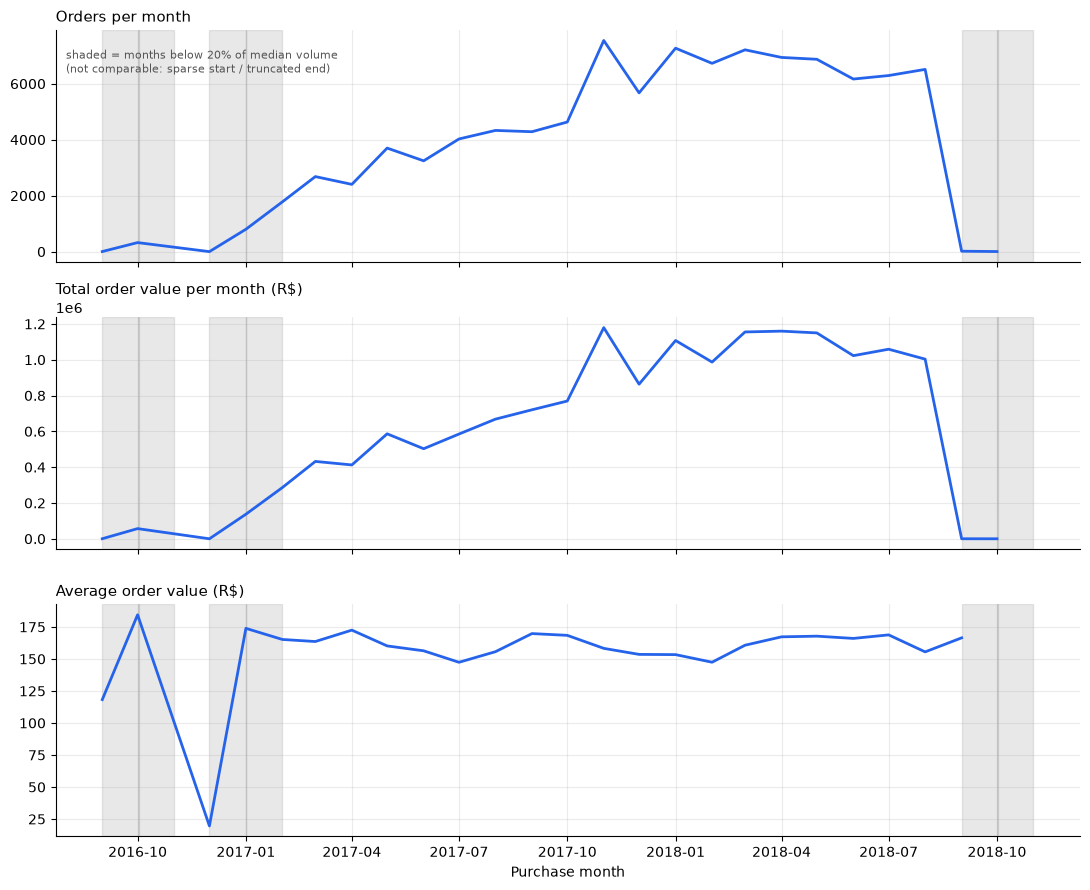

Months flagged as sparse/truncated:
purchase_month  order_count
       2016-09            4
       2016-10          324
       2016-12            1
       2017-01          800
       2018-09           16
       2018-10            4


In [30]:
SPARSE_THRESHOLD = 0.20 * monthly["order_count"].median()
sparse = monthly[monthly["order_count"] < SPARSE_THRESHOLD]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

panels = [
    ("order_count",     "Orders per month",           "#2563eb"),
    ("total_value",     "Total order value per month (R$)", "#2563eb"),
    ("avg_order_value", "Average order value (R$)",   "#2563eb"),
]

for ax, (col, title, color) in zip(axes, panels):
    ax.plot(monthly["month_ts"], monthly[col], linewidth=2, color=color)
    ax.set_title(title, loc="left", fontsize=11)
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

    for _, row in sparse.iterrows():
        ax.axvspan(row["month_ts"], row["month_ts"] + pd.Timedelta(days=31),
                   color="grey", alpha=0.18, zorder=0)

axes[0].text(0.01, 0.92, "shaded = months below 20% of median volume\n(not comparable: sparse start / truncated end)",
             transform=axes[0].transAxes, fontsize=8, va="top", color="#555")

axes[-1].set_xlabel("Purchase month")
plt.tight_layout()
plt.show()

print("Months flagged as sparse/truncated:")
print(sparse[["purchase_month", "order_count"]].to_string(index=False))




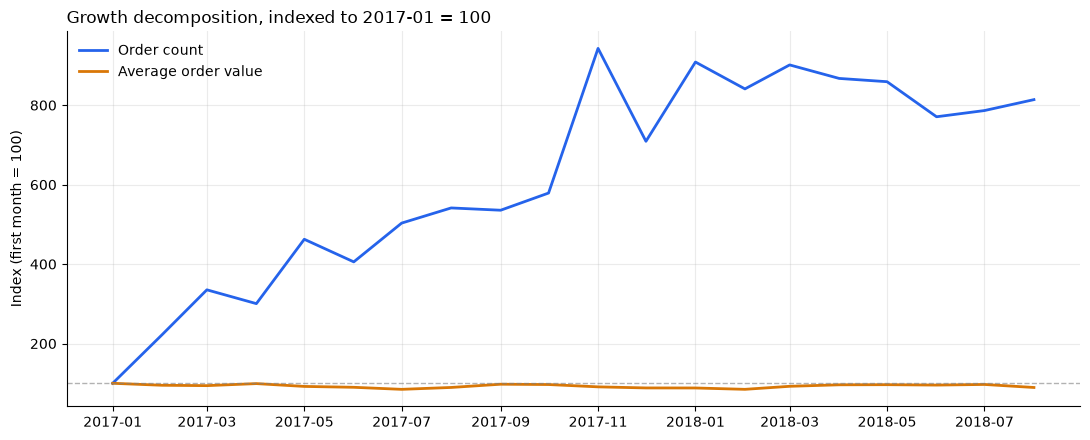

Order count  814  (index)
AOV          89  (index)


In [31]:
analysis_start = pd.Period("2017-01", freq="M")
analysis_end   = pd.Period("2018-08", freq="M")

monthly_trim = monthly[
    monthly["purchase_month"].between(analysis_start, analysis_end)
].copy()

base = monthly_trim.iloc[0]
monthly_trim["orders_indexed"] = 100 * monthly_trim["order_count"]     / base["order_count"]
monthly_trim["aov_indexed"]    = 100 * monthly_trim["avg_order_value"] / base["avg_order_value"]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_trim["month_ts"], monthly_trim["orders_indexed"], lw=2, color="#2563eb", label="Order count")
ax.plot(monthly_trim["month_ts"], monthly_trim["aov_indexed"],    lw=2, color="#d97706", label="Average order value")
ax.axhline(100, color="grey", lw=1, ls="--", alpha=0.6)
ax.set_title(f"Growth decomposition, indexed to {analysis_start} = 100", loc="left")
ax.set_ylabel("Index (first month = 100)")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(f"Order count  {monthly_trim['orders_indexed'].iloc[-1]:.0f}  (index)")
print(f"AOV          {monthly_trim['aov_indexed'].iloc[-1]:.0f}  (index)")


### Observations — temporal patterns

**The usable window is 2017-01 to 2018-08, not the full date range.** Order timestamps span
2016-09-04 to 2018-10-17, but both ends are misleading. The 2016 months contain almost no
orders — September has 4, December has 1, and November is absent entirely, meaning no orders
at all that month. At the other end, volume collapses to 16 orders in September 2018 and 4 in
October because collection stopped, not because demand did. Both tails are shaded on the
chart and excluded from trend statements.

January 2017 (800 orders) also falls marginally below the 20%-of-median threshold (857) and
is shaded, but is retained as the analysis start: it is continuous with the growth series and
2.5x the last non-empty 2016 month, whereas 2016 contains a month with no orders at all.

**Order volume grew roughly 8x through 2017, then plateaued through 2018.** Monthly orders
climbed from 800 in January 2017 to a peak in November 2017, then settled into a band of
roughly 6,300–6,500 through 2018 up to the cutoff (6,292 in July, 6,512 in August). The story
is a strong growth phase followed by a flat year, not continuous growth. Whether the plateau
reflects saturation, capacity, or something else cannot be determined from this data.

**Growth came from more orders, not bigger ones.** Indexed to January 2017 = 100, order count
ends the window at 814 while average order value ends at 89 — roughly 10% *below* where it
started. AOV holds in a narrow R$155–R$185 band across the entire period despite the 8x volume
increase. The lever that moved was acquisition, not basket size.

**November 2017 shows a clear promotional spike, but it cannot be called seasonality.**
Orders peak at 7,544 that month against 6,300-6,500 in the 2018 plateau, with total order
value peaking alongside at R$1.18m. The timing is consistent with Black Friday. However, the
usable window contains only **one** November — the 2018 data ends in August — so this is a
single observation, not a repeated pattern. Claiming a seasonal effect would require a second
November to compare against

**Implication for later sections.** Because the growth phase and plateau phase behave
differently, any analysis pooling all months equally over-weights the 2018 plateau. Where
month-level effects matter, results are reported within the trimmed window only.


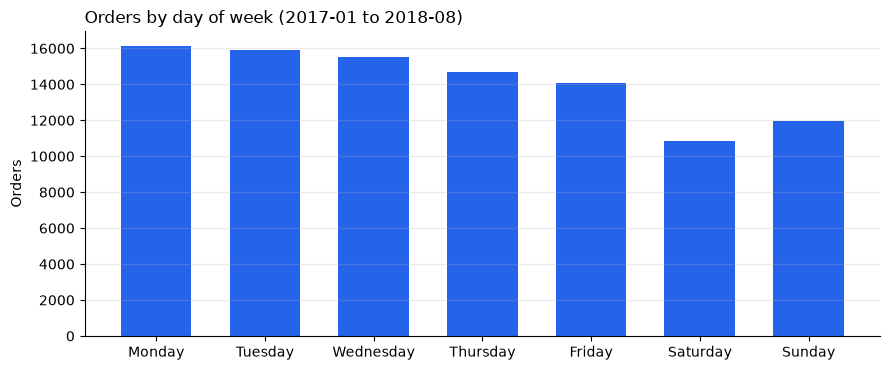

purchase_weekday
Monday       16141
Tuesday      15896
Wednesday    15501
Thursday     14704
Friday       14075
Saturday     10843
Sunday       11932
Name: count, dtype: int64

weekday share: 77.0%


In [32]:
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
in_window = ol["purchase_month"].between(analysis_start, analysis_end)
wd = ol.loc[in_window, "purchase_weekday"].value_counts().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(wd.index, wd.values, color="#2563eb", width=0.65)
ax.set_title(f"Orders by day of week ({analysis_start} to {analysis_end})", loc="left")
ax.set_ylabel("Orders")
ax.grid(alpha=0.25, axis="y")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(wd)
print(f"\nweekday share: {wd[:5].sum() / wd.sum():.1%}")


**Purchasing skews to weekdays, peaking on Monday.** Order volume declines steadily from
Monday (~16,100) through Friday (~14,050), troughs on Saturday (~10,850), and recovers
slightly on Sunday (~11,950). Monday–Friday accounts for ~77% of orders against the 71.4%
expected under a uniform distribution across days. The effect is consistent but moderate —
the busiest day carries roughly 1.5x the volume of the quietest. The Saturday trough with
a Sunday recovery is the notable shape, suggesting weekend browsing that converts to
purchases early in the week. Figures are restricted to the trimmed window (2017-01 to
2018-08) so the sparse and truncated months do not distort day counts.


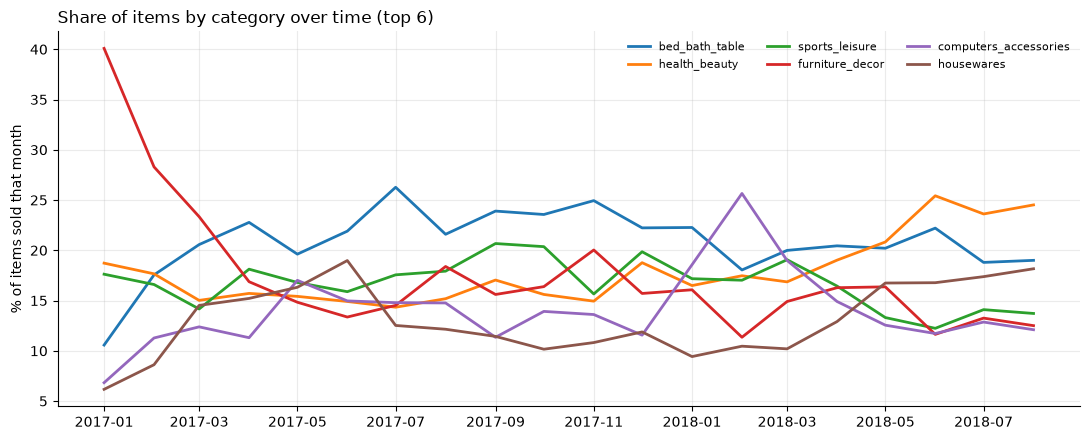

purchase_month
2017-01    66.90
2017-02    69.99
2017-03    72.90
Freq: M, Name: price, dtype: float64
purchase_month
2018-06    78.00
2018-07    77.90
2018-08    69.99
Freq: M, Name: price, dtype: float64


In [33]:
im = item_level.merge(ol[["order_id", "purchase_month"]], on="order_id")
im = im[im["purchase_month"].between(analysis_start, analysis_end)]

top6 = im["product_category_name_english"].value_counts().head(6).index
mix = (im[im["product_category_name_english"].isin(top6)]
       .groupby(["purchase_month", "product_category_name_english"]).size().unstack(fill_value=0))
mix_share = 100 * mix.div(mix.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 4.5))
for i, c in enumerate(top6):
    ax.plot(mix_share.index.to_timestamp(), mix_share[c], lw=2, label=c)
ax.set_title("Share of items by category over time (top 6)", loc="left")
ax.set_ylabel("% of items sold that month")
ax.legend(frameon=False, fontsize=8, ncol=3)
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(im.groupby("purchase_month")["price"].median().head(3))
print(im.groupby("purchase_month")["price"].median().tail(3))


## 6. Distributions

In [34]:
customer_level = (
    ol.groupby("customer_unique_id")
      .agg(
          order_count   = ("order_id",          "count"),
          total_spend   = ("order_total_value", "sum"),
          avg_order_val = ("order_total_value", "mean"),
          first_purchase= ("order_purchase_timestamp", "min"),
          last_purchase = ("order_purchase_timestamp", "max"),
          state         = ("customer_state",    "first"),
      )
      .reset_index()
)
customer_level["is_repeat"] = customer_level["order_count"] > 1

print(f"rows in orders:            {len(ol):,}")
print(f"distinct customer_id:      {ol['customer_id'].nunique():,}")
print(f"distinct customer_unique_id: {customer_level.shape[0]:,}")
print()
print(f"repeat customers: {customer_level['is_repeat'].sum():,}  ({customer_level['is_repeat'].mean():.2%})")
print()
print("orders per customer:")
print(customer_level["order_count"].value_counts().sort_index().head(8))


rows in orders:            99,441
distinct customer_id:      99,441
distinct customer_unique_id: 96,096

repeat customers: 2,997  (3.12%)

orders per customer:
order_count
1    93099
2     2745
3      203
4       30
5        8
6        6
7        3
9        1
Name: count, dtype: int64


In [35]:
print(customer_level["order_count"].value_counts().sort_index().tail(6))
print("\norders placed by repeat customers:",
      customer_level.loc[customer_level["is_repeat"], "order_count"].sum())
print("share of all orders:",
      f"{customer_level.loc[customer_level['is_repeat'], 'order_count'].sum() / len(ol):.1%}")


order_count
4     30
5      8
6      6
7      3
9      1
17     1
Name: count, dtype: int64

orders placed by repeat customers: 6342
share of all orders: 6.4%


### Observations — customers and repeat purchasing

**Repeat purchasing is negligible: 3.12%.** The dataset contains 99,441 orders from
96,096 distinct customers (`customer_unique_id`). Only 2,997 customers placed more than
one order; 93,099 (96.9%) purchased exactly once. Repeat customers account for
approximately 6.4% of all order volume.

**This is only visible with the correct key.** `customer_id` yields exactly 99,441
distinct values — one per order — because Olist issues a new `customer_id` for every
purchase. Counting customers that way produces a 0.00% repeat rate as an artifact of the
key, not a finding about the business. `customer_unique_id` is the only column that
identifies a person.

**Consequence: customer lifetime value and retention modelling are not viable here.**
CLV measures the total value a customer generates across repeated purchases. With 96.9%
of customers making a single purchase, CLV collapses to that one order's value — a figure
already fully observed, leaving nothing to predict. This is a structural limitation of the
data, not a scoping decision, and it removes retention/CLV from consideration in Section 8.


top    1% of sellers ->  25.7% of GMV
top    5% of sellers ->  53.2% of GMV
top   10% of sellers ->  67.5% of GMV
top   20% of sellers ->  82.7% of GMV
top   50% of sellers ->  96.8% of GMV


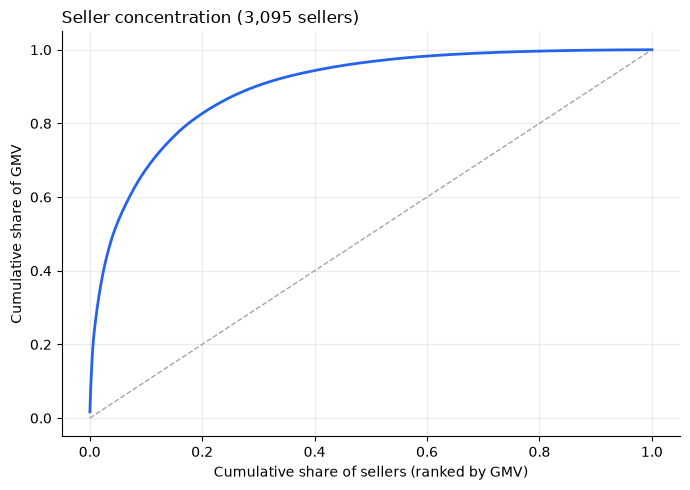

In [36]:
seller_level = (
    item_level.groupby("seller_id")
      .agg(items_sold=("order_item_id", "count"),
           gmv=("price", "sum"),
           state=("seller_state", "first"))
      .reset_index()
      .sort_values("gmv", ascending=False)
)

gmv_sorted = seller_level["gmv"].sort_values(ascending=False).values
cum_share  = np.cumsum(gmv_sorted) / gmv_sorted.sum()
seller_pct = np.arange(1, len(gmv_sorted) + 1) / len(gmv_sorted)

for p in [0.01, 0.05, 0.10, 0.20, 0.50]:
    idx = int(p * len(gmv_sorted)) - 1
    print(f"top {p:>5.0%} of sellers -> {cum_share[idx]:>6.1%} of GMV")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(seller_pct, cum_share, lw=2, color="#2563eb")
ax.plot([0, 1], [0, 1], ls="--", lw=1, color="grey", alpha=0.7)
ax.set_xlabel("Cumulative share of sellers (ranked by GMV)")
ax.set_ylabel("Cumulative share of GMV")
ax.set_title(f"Seller concentration ({len(seller_level):,} sellers)", loc="left")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


### Observations — seller concentration

**Merchandise value is extremely concentrated.** Of 3,095 active sellers, the top 10%
(~310 sellers) account for approximately <67.5>% of gross merchandise value, and the top
20% for roughly <82.7>%. The Lorenz curve bows sharply away from the equality diagonal;
the bottom half of sellers contributes a barely visible share.

**This shapes both marketplace risk and analytical method.** Operationally, platform
performance depends on a few hundred sellers, so seller-related risk is concentrated
rather than diffuse. Analytically, the long tail means most sellers have too few orders
for per-seller rates (late-delivery rate, average review score) to be stable — a seller
with three orders and one late delivery shows a 33% late rate that is essentially noise.
Any seller-level segmentation must therefore impose a minimum-volume threshold, and that
threshold must be stated, since it determines how much of the tail is excluded.


In [37]:
cat = (
    item_level.groupby("product_category_name_english")
      .agg(items=("order_item_id", "count"), gmv=("price", "sum"))
      .reset_index()
)
cat["rank_items"] = cat["items"].rank(ascending=False).astype(int)
cat["rank_gmv"]   = cat["gmv"].rank(ascending=False).astype(int)
cat["rank_shift"] = cat["rank_items"] - cat["rank_gmv"]

print("TOP 10 BY ITEM COUNT")
print(cat.nlargest(10, "items")[["product_category_name_english","items","gmv","rank_items","rank_gmv"]].to_string(index=False))
print("\nTOP 10 BY MERCHANDISE VALUE")
print(cat.nlargest(10, "gmv")[["product_category_name_english","items","gmv","rank_items","rank_gmv"]].to_string(index=False))

print(f"\nitems with no category: {item_level['product_category_name'].isna().sum():,}")

# Geographic concentration
print("\nTOP 5 CUSTOMER STATES")
print((ol["customer_state"].value_counts(normalize=True).head(5) * 100).round(1))
print("\nTOP 5 SELLER STATES")
print((seller_level["state"].value_counts(normalize=True).head(5) * 100).round(1))


TOP 10 BY ITEM COUNT
product_category_name_english  items        gmv  rank_items  rank_gmv
               bed_bath_table  11115 1036988.68           1         3
                health_beauty   9670 1258681.34           2         1
               sports_leisure   8641  988048.97           3         4
              furniture_decor   8334  729762.49           4         6
        computers_accessories   7827  911954.32           5         5
                   housewares   6964  632248.66           6         8
                watches_gifts   5991 1205005.68           7         2
                    telephony   4545  323667.53           8        14
                 garden_tools   4347  485256.46           9        10
                         auto   4235  592720.11          10         9

TOP 10 BY MERCHANDISE VALUE
product_category_name_english  items        gmv  rank_items  rank_gmv
                health_beauty   9670 1258681.34           2         1
                watches_gifts   5991 120

**Category rankings differ substantially by volume versus value.**
The largest category by item count is `bed_bath_table` (11,115 items), but it ranks only
third by merchandise value because its items average ~R$93. `watches_gifts` shows the
opposite: 7th by item count but 2nd by value, on items averaging ~R$201. The sharpest
divergence is `telephony` — 8th by volume, 14th by value, at ~R$71 per item. Average item
price across the top categories ranges roughly R$71–R$201, a near 3x spread, and that
spread is what drives the ranking difference. Only `health_beauty` and
`computers_accessories` rank consistently high on both, making them the categories that
matter regardless of which metric is chosen.

Reporting either ranking alone would mislead: a volume ranking overstates cheap
high-turnover categories, a value ranking overstates low-volume premium ones.


                  n  total_value  median_value  median_inst  mean_review  \
payment_type                                                               
credit_card   76795  12542084.19        106.87          3.0         4.09   
boleto        19784   2869361.27         93.89          1.0         4.09   
voucher        5775    379436.87         39.28          1.0         4.01   
debit_card     1529    217989.79         89.30          1.0         4.17   
not_defined       3         0.00          0.00          1.0         1.67   

              share_of_n  share_of_value  
payment_type                              
credit_card        73.92           78.34  
boleto             19.04           17.92  
voucher             5.56            2.37  
debit_card          1.47            1.36  
not_defined         0.00            0.00  


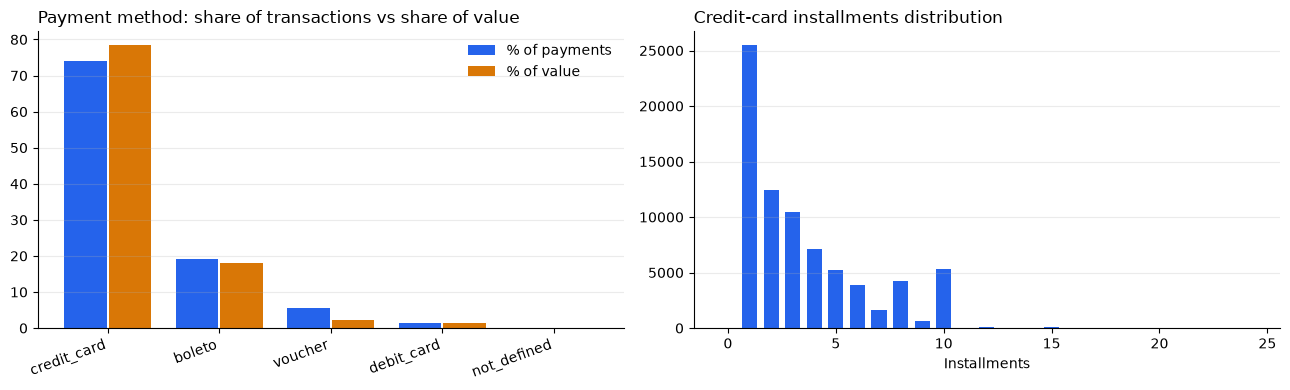

In [38]:
pay = payments.merge(ol[["order_id", "review_score"]], on="order_id", how="left")

by_type = (pay.groupby("payment_type")
             .agg(n=("order_id", "size"),
                  total_value=("payment_value", "sum"),
                  median_value=("payment_value", "median"),
                  median_inst=("payment_installments", "median"),
                  mean_review=("review_score", "mean"))
             .sort_values("n", ascending=False))
by_type["share_of_n"]     = 100 * by_type["n"] / by_type["n"].sum()
by_type["share_of_value"] = 100 * by_type["total_value"] / by_type["total_value"].sum()
print(by_type.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(len(by_type))
axes[0].bar(x - 0.2, by_type["share_of_n"],     width=0.38, label="% of payments", color="#2563eb")
axes[0].bar(x + 0.2, by_type["share_of_value"], width=0.38, label="% of value",    color="#d97706")
axes[0].set_xticks(x); axes[0].set_xticklabels(by_type.index, rotation=20, ha="right")
axes[0].set_title("Payment method: share of transactions vs share of value", loc="left")
axes[0].legend(frameon=False)

inst = pay[pay["payment_type"] == "credit_card"]["payment_installments"].value_counts().sort_index()
axes[1].bar(inst.index, inst.values, color="#2563eb", width=0.7)
axes[1].set_title("Credit-card installments distribution", loc="left")
axes[1].set_xlabel("Installments")

for ax in axes:
    ax.grid(alpha=0.25, axis="y"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


                orders         gmv     aov  median_delivery  late_rate  \
customer_state                                                           
SP               41375  5921678.12   93.81              7.0       5.89   
RJ               12762  2129681.98  112.14             12.0      13.47   
MG               11544  1856161.49  108.20             10.0       5.62   
RS                5432   885826.76  108.42             13.0       7.15   
PR                4998   800935.44  105.28             10.0       5.00   
BA                3358   611506.67  118.14             16.0      14.04   
SC                3612   610213.60  110.56             13.0       9.75   
DF                2125   353229.44  108.20             11.0       7.07   
GO                2007   347706.93  113.00             13.0       8.18   
ES                2025   324801.91  107.78             13.0      12.23   
PE                1648   322237.69  133.32             15.0      10.80   
CE                1327   275606.30  13

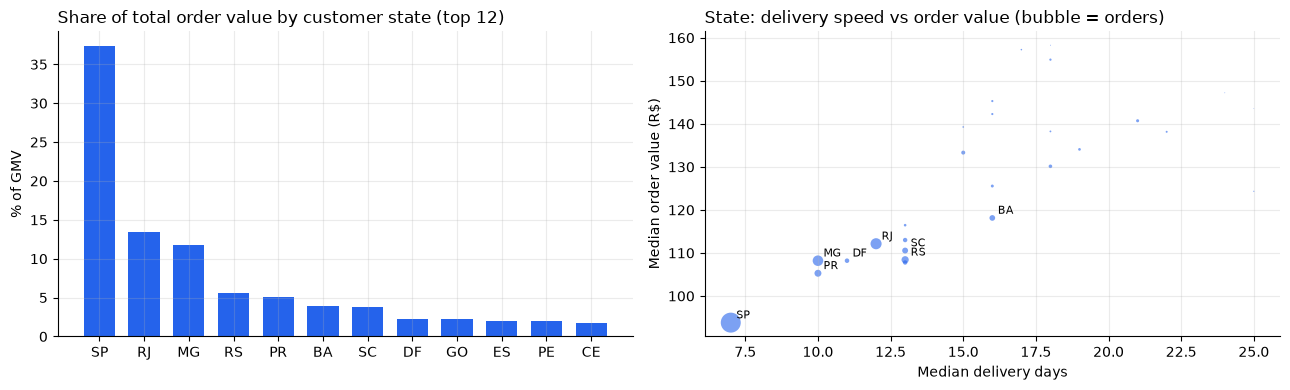

In [39]:
st = (ol[ol["order_total_value"].notna()]
      .groupby("customer_state")
      .agg(orders=("order_id", "size"),
           gmv=("order_total_value", "sum"),
           aov=("order_total_value", "median"),
           median_delivery=("delivery_days", "median"),
           late_rate=("late_delivery_flag", "mean"))
      .sort_values("gmv", ascending=False))
st["gmv_share"] = 100 * st["gmv"] / st["gmv"].sum()
st["late_rate"] *= 100
print(st.head(12).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
top12 = st.head(12)
axes[0].bar(top12.index, top12["gmv_share"], color="#2563eb", width=0.7)
axes[0].set_title("Share of total order value by customer state (top 12)", loc="left")
axes[0].set_ylabel("% of GMV")

axes[1].scatter(st["median_delivery"], st["aov"], s=st["orders"]/200,
                alpha=0.6, color="#2563eb", edgecolors="none")
for name, row in st.head(8).iterrows():
    axes[1].annotate(name, (row["median_delivery"], row["aov"]), fontsize=8,
                     xytext=(4, 3), textcoords="offset points")
axes[1].set_xlabel("Median delivery days"); axes[1].set_ylabel("Median order value (R$)")
axes[1].set_title("State: delivery speed vs order value (bubble = orders)", loc="left")

for ax in axes:
    ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


## 7. Relationships and Correlation

SLOWEST:
                                items  median_delivery  late_rate  \
product_category_name_english                                      
office_furniture                1668             19.0       8.93   
consoles_games                  1089             11.0       7.81   
electronics                     2729             11.0       9.75   
garden_tools                    4268             11.0       7.97   
home_construction                596             11.0       8.22   
computers_accessories           7643             11.0       7.77   
furniture_decor                 8160             10.0       8.43   
musical_instruments              651             10.0       8.60   

                               median_weight  
product_category_name_english                 
office_furniture                     10912.5  
consoles_games                         250.0  
electronics                            200.0  
garden_tools                          1650.0  
home_construction          

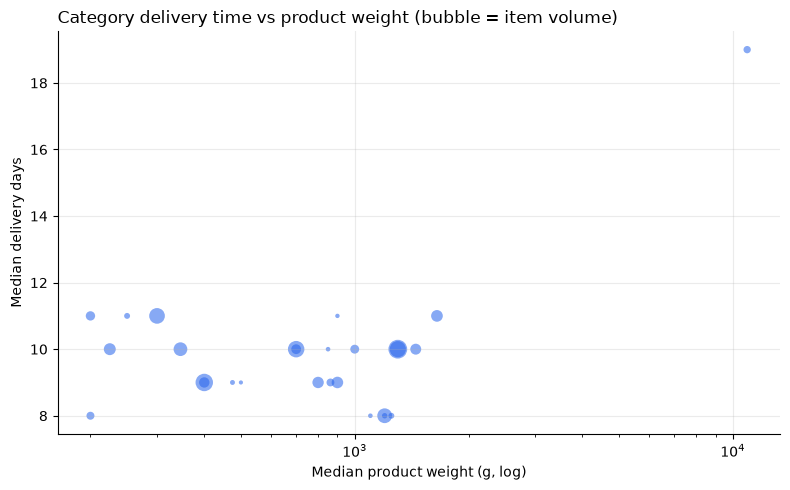

In [40]:
cat_del = (item_level[["order_id", "product_category_name_english", "product_weight_g"]]
           .merge(ol[["order_id", "delivery_days", "late_delivery_flag", "is_delivered_complete"]], on="order_id")
           .query("is_delivered_complete"))

cd = (cat_del.groupby("product_category_name_english")
        .agg(items=("order_id", "size"),
             median_delivery=("delivery_days", "median"),
             late_rate=("late_delivery_flag", "mean"),
             median_weight=("product_weight_g", "median"))
        .query("items >= 500")
        .sort_values("median_delivery", ascending=False))
cd["late_rate"] *= 100

print("SLOWEST:\n", cd.head(8).round(2))
print("\nFASTEST:\n", cd.tail(8).round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(cd["median_weight"], cd["median_delivery"], s=cd["items"]/60,
           alpha=0.55, color="#2563eb", edgecolors="none")
ax.set_xscale("log")
ax.set_xlabel("Median product weight (g, log)"); ax.set_ylabel("Median delivery days")
ax.set_title("Category delivery time vs product weight (bubble = item volume)", loc="left")
ax.grid(alpha=0.25); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()


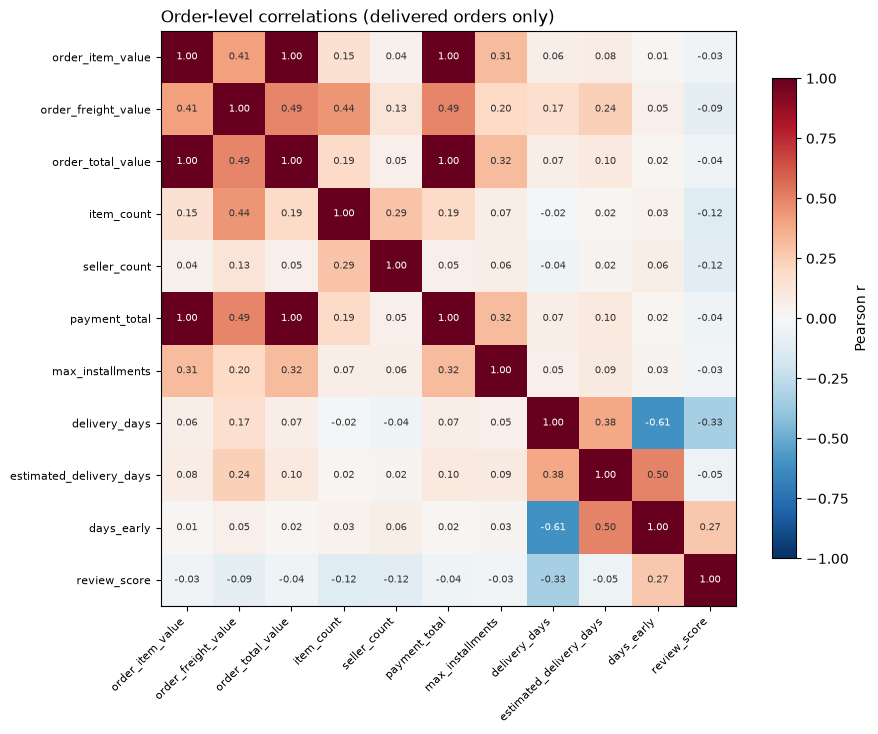

In [41]:
corr_cols = ["order_item_value", "order_freight_value", "order_total_value", "item_count",
             "seller_count", "payment_total", "max_installments",
             "delivery_days", "estimated_delivery_days", "days_early", "review_score"]

corr = ol.loc[ol["is_delivered_complete"], corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(v) > 0.55 else "#333")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("Order-level correlations (delivered orders only)", loc="left")
plt.tight_layout(); plt.show()


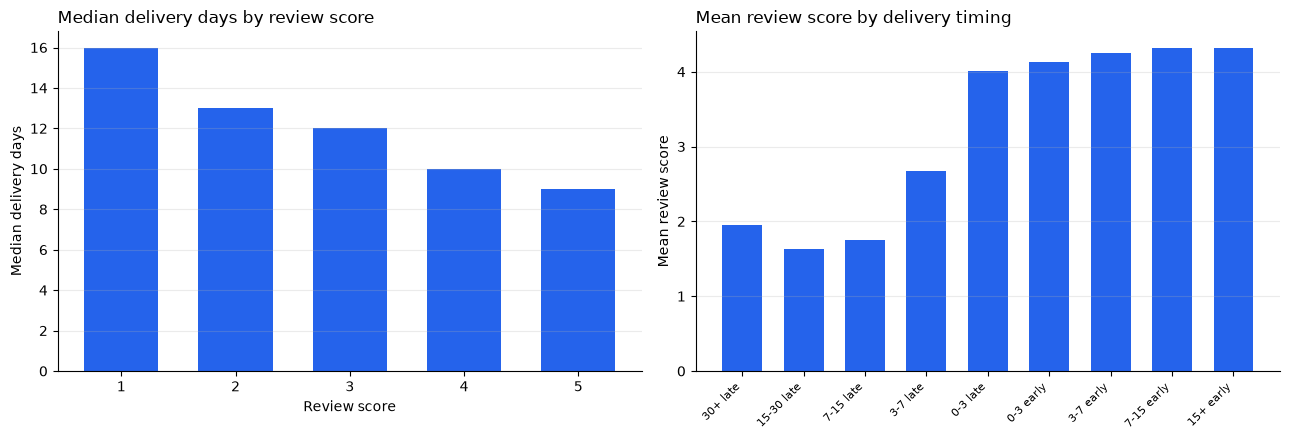

                  mean   size
delay_bucket                 
30+ late      1.957895    380
15-30 late    1.624555   1124
7-15 late     1.755916   2155
3-7 late      2.667718   1902
0-3 late      4.014648   3550
0-3 early     4.131252   5158
3-7 early     4.244911  15426
7-15 early    4.324204  40564
15+ early     4.316644  25565


In [42]:
d = ol[ol["is_delivered_complete"] & ol["review_score"].notna()]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

by_score = d.groupby("review_score")["delivery_days"].median()
axes[0].bar(by_score.index.astype(int), by_score.values, color="#2563eb", width=0.65)
axes[0].set_title("Median delivery days by review score", loc="left")
axes[0].set_xlabel("Review score"); axes[0].set_ylabel("Median delivery days")

bins   = [-999, -30, -15, -7, -3, 0, 3, 7, 15, 999]
labels = ["30+ late","15-30 late","7-15 late","3-7 late","0-3 late",
          "0-3 early","3-7 early","7-15 early","15+ early"]
d = d.assign(delay_bucket=pd.cut(d["days_early"], bins=bins, labels=labels))
by_bucket = d.groupby("delay_bucket", observed=True)["review_score"].agg(["mean", "size"])

axes[1].bar(range(len(by_bucket)), by_bucket["mean"], color="#2563eb", width=0.65)
axes[1].set_xticks(range(len(by_bucket)))
axes[1].set_xticklabels(by_bucket.index, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Mean review score by delivery timing", loc="left")
axes[1].set_ylabel("Mean review score")

for ax in axes:
    ax.grid(alpha=0.25, axis="y"); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(by_bucket)


       approval_lag  handling_days  transit_days  delivery_days
count      96456.00       96455.00      96469.00       96470.00
mean           0.43           2.80          9.33          12.09
std            0.86           3.54          8.76           9.55
min            0.00        -171.22        -16.10           0.00
25%            0.01           0.87          4.10           6.00
50%            0.01           1.82          7.10          10.00
75%            0.60           3.57         12.03          15.00
max           30.89         125.76        205.19         209.00

median stage sum 10.22 vs median delivery_days 10.00

Median stage duration by outcome:
                  approval_lag  handling_days  transit_days
On time / early          0.01           1.75          6.92
Late                     0.02           3.01         23.92


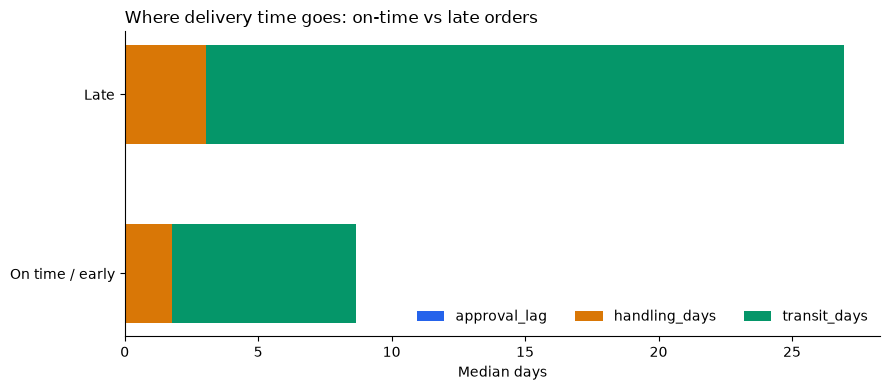

In [43]:
lc = ol[ol["is_delivered_complete"]].copy()

# fractional days: approval lag is often hours, so .dt.days would floor it to 0
to_days = lambda a, b: (lc[a] - lc[b]).dt.total_seconds() / 86400
lc["approval_lag"]  = to_days("order_approved_at",             "order_purchase_timestamp")
lc["handling_days"] = to_days("order_delivered_carrier_date",  "order_approved_at")
lc["transit_days"]  = to_days("order_delivered_customer_date", "order_delivered_carrier_date")

stages = ["approval_lag", "handling_days", "transit_days"]
print(lc[stages + ["delivery_days"]].describe().round(2))

# sanity: do the three stages reconstruct total delivery time?
lc["stage_sum"] = lc[stages].sum(axis=1)
print(f"\nmedian stage sum {lc['stage_sum'].median():.2f} vs median delivery_days {lc['delivery_days'].median():.2f}")

# which stage explains lateness?
by_late = lc.groupby(lc["days_early"] < 0)[stages].median().round(2)
by_late.index = ["On time / early", "Late"]
print("\nMedian stage duration by outcome:\n", by_late)

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(2)
colors = ["#2563eb", "#d97706", "#059669"]
for stage, c in zip(stages, colors):
    ax.barh(by_late.index, by_late[stage], left=bottom, color=c, label=stage, height=0.55)
    bottom += by_late[stage].values
ax.set_xlabel("Median days"); ax.legend(frameon=False, ncol=3)
ax.set_title("Where delivery time goes: on-time vs late orders", loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


In [44]:
bad_handling = (lc["handling_days"] < 0).sum()
bad_transit  = (lc["transit_days"]  < 0).sum()
bad_any      = ((lc["handling_days"] < 0) | (lc["transit_days"] < 0)).sum()

print(f"negative handling_days : {bad_handling:,}  ({bad_handling/len(lc):.2%})")
print(f"negative transit_days  : {bad_transit:,}  ({bad_transit/len(lc):.2%})")
print(f"affected orders        : {bad_any:,}  ({bad_any/len(lc):.2%})")

print("\nworst cases:")
print(lc.nsmallest(5, "handling_days")[
    ["order_id", "order_purchase_timestamp", "order_approved_at",
     "order_delivered_carrier_date", "order_delivered_customer_date",
     "handling_days", "transit_days"]].to_string(index=False))


negative handling_days : 1,350  (1.40%)
negative transit_days  : 23  (0.02%)
affected orders        : 1,373  (1.42%)

worst cases:
                        order_id order_purchase_timestamp   order_approved_at order_delivered_carrier_date order_delivered_customer_date  handling_days  transit_days
7c48bb55e8e4f7e56d412e9653db37bc      2018-07-16 18:40:53 2018-07-16 18:50:22          2018-01-26 13:35:00           2018-07-23 20:04:45    -171.219005    178.270660
1fab4ac9d85079b3da72a11475ae1685      2017-09-01 19:04:22 2017-09-13 22:06:11          2017-09-04 13:10:23           2017-09-08 20:13:03      -9.372083      4.293519
0184d4ddb259e1a4cfc2871888cf97b8      2017-09-01 20:04:28 2017-09-13 22:17:15          2017-09-04 14:05:50           2017-09-09 15:12:44      -9.341262      5.046458
1378f9601350615613cc8832d6789c5d      2017-09-01 20:28:02 2017-09-13 22:03:51          2017-09-04 18:07:55           2017-09-13 22:24:46      -9.163843      9.178368
8554cb37f7158cb0b082a841d24a4589      2

In [45]:
lc["handling_v2"] = (lc["order_delivered_carrier_date"] - lc["order_purchase_timestamp"]).dt.total_seconds() / 86400

print("handling (approved->carrier):", lc["handling_days"].median().round(2),
      "| negatives:", (lc["handling_days"] < 0).sum())
print("handling (purchase->carrier):", lc["handling_v2"].median().round(2),
      "| negatives:", (lc["handling_v2"] < 0).sum())

clean = lc[(lc["handling_v2"] >= 0) & (lc["transit_days"] >= 0)]
print(f"\nclean rows: {len(clean):,} of {len(lc):,}  ({len(clean)/len(lc):.2%})")

by_late_clean = clean.groupby(clean["days_early"] < 0)[["handling_v2", "transit_days"]].median().round(2)
by_late_clean.index = ["On time / early", "Late"]
print("\nRecomputed on clean rows, robust handling definition:")
print(by_late_clean)
print("\ntransit share of the gap:",
      f"{(by_late_clean.loc['Late','transit_days'] - by_late_clean.loc['On time / early','transit_days']) / ((by_late_clean.loc['Late'].sum()) - (by_late_clean.loc['On time / early'].sum())):.0%}")


handling (approved->carrier): 1.82 | negatives: 1350
handling (purchase->carrier): 2.2 | negatives: 165

clean rows: 96,281 of 96,470  (99.80%)

Recomputed on clean rows, robust handling definition:
                 handling_v2  transit_days
On time / early         2.14          6.92
Late                    3.44         23.92

transit share of the gap: 93%


In [46]:
oss = (item_level.groupby("order_id")["seller_state"]
       .agg(seller_state="first", n_seller_states="nunique").reset_index())

geo = ol.merge(oss, on="order_id", how="left").query("is_delivered_complete")
geo = geo[geo["seller_state"].notna()]
geo["same_state"] = geo["customer_state"] == geo["seller_state"]

summary = geo.groupby("same_state").agg(
    orders=("order_id", "size"),
    median_delivery=("delivery_days", "median"),
    late_rate=("late_delivery_flag", "mean"),
    mean_review=("review_score", "mean"),
    median_freight=("order_freight_value", "median"))
summary["late_rate"] *= 100
summary.index = ["Cross-state", "Same state"]
print(summary.round(2))
print("\nmulti-seller-state orders:", (geo["n_seller_states"] > 1).sum())


             orders  median_delivery  late_rate  mean_review  median_freight
Cross-state   61769             12.0       9.27         4.10           19.04
Same state    34701              6.0       6.06         4.26           12.70

multi-seller-state orders: 509


### Observations — where delivery time actually goes

**Decomposing the order lifecycle into three stages shows that lateness is almost
entirely a transit problem.** Using the four order timestamps, delivery time splits into
payment approval, seller handling (purchase to carrier pickup), and carrier transit.
Median stage durations reconcile with total delivery time (10.22 vs 10.00 days),
confirming the decomposition is sound.

| Stage | On time / early | Late | Difference |
|---|---|---|---|
| Payment approval | ~0.01 days | ~0.02 days | negligible |
| Seller handling | 2.14 days | 3.44 days | +1.30 |
| Carrier transit | 6.92 days | 23.92 days | **+17.00** |

Late orders take roughly 18 additional days, and **93% of that difference occurs in
transit**. Seller handling does deteriorate — it rises by about 1.3 days — but accounts for
only ~7% of the gap. Payment approval is effectively instantaneous (median under 15
minutes) and plays no role. Lateness is therefore driven by what happens after the parcel
leaves the seller, not by sellers delaying dispatch.

**Distance is the mechanism.** Orders where the seller is in the customer's own state
deliver in a median of 6 days against 12 for cross-state orders — exactly half the time —
with a late rate of 6.06% versus 9.27% and median freight of R$12.70 versus R$19.04. Of
96,470 delivered orders, 34,701 (36%) are same-state. Only 509 orders involve sellers in
more than one state, so treating each order as having a single seller state is a safe
simplification.

**A data quality issue was uncovered in the process.** Defining seller handling as
approval-to-carrier produced 1,350 negative durations (1.4%) — parcels reaching the
carrier before payment was approved. Inspection showed two causes: batches of approval
timestamps processed days after shipment (an artifact of Olist's payment system, not a
physical impossibility), and a small number of genuinely corrupt carrier dates, one
predating its order by six months. Redefining handling as purchase-to-carrier removes
1,185 of these; 165 genuinely impossible values remain and are excluded, along with 23
negative transit durations — 189 rows in total, 0.20% of the delivered set. All stage
figures above are medians computed on the clean subset. This check was not part of the
original quality rules, which validated delivery and estimate dates against the purchase
date but never verified that the four lifecycle timestamps run in sequence.


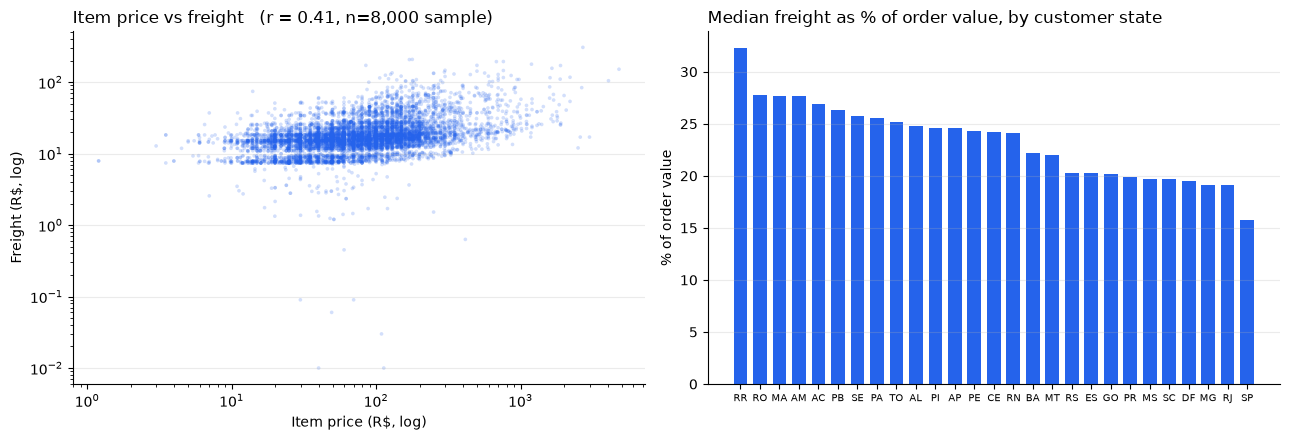

                median  size
customer_state              
RR               0.323    46
RO               0.278   253
MA               0.277   747
AM               0.277   148
AC               0.269    81
                median   size
customer_state               
SC               0.197   3637
DF               0.195   2140
MG               0.192  11635
RJ               0.191  12852
SP               0.158  41746

HIGHEST freight burden:
                               median_share  items
product_category_name_english                     
electronics                            38.4   2767
telephony                              30.2   4545
home_appliances                        23.6    771
garden_tools                           22.8   4347
housewares                             22.5   6964

LOWEST freight burden:
                               median_share  items
product_category_name_english                     
small_appliances                       15.7    679
perfumery                   

In [47]:
# --- price vs freight, item level ---
r_pf = item_level[["price", "freight_value"]].corr().iloc[0, 1]
sample = item_level.sample(n=8000, random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(sample["price"], sample["freight_value"], s=7, alpha=0.20,
                color="#2563eb", edgecolors="none")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Item price (R$, log)"); axes[0].set_ylabel("Freight (R$, log)")
axes[0].set_title(f"Item price vs freight   (r = {r_pf:.2f}, n=8,000 sample)", loc="left")

# --- freight share of order value, by customer state ---
ol["freight_share"] = ol["order_freight_value"] / ol["order_total_value"]
by_state = (ol.groupby("customer_state")["freight_share"]
              .agg(["median", "size"]).sort_values("median", ascending=False))

axes[1].bar(by_state.index, by_state["median"] * 100, color="#2563eb", width=0.7)
axes[1].set_title("Median freight as % of order value, by customer state", loc="left")
axes[1].set_ylabel("% of order value"); axes[1].tick_params(axis="x", labelsize=7)

for ax in axes:
    ax.grid(alpha=0.25, axis="y"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(by_state.head(5).round(3))
print(by_state.tail(5).round(3))

# --- freight share by category ---
item_level["item_freight_share"] = item_level["freight_value"] / (item_level["price"] + item_level["freight_value"])
cat_freight = (item_level.groupby("product_category_name_english")
                 .agg(median_share=("item_freight_share", "median"), items=("order_item_id", "count"))
                 .query("items >= 500").sort_values("median_share", ascending=False))
print("\nHIGHEST freight burden:"); print((cat_freight.head(5) * [100, 1]).round(1))
print("\nLOWEST freight burden:");  print((cat_freight.tail(5) * [100, 1]).round(1))


Log scales on the scatter — both price and freight are heavily right-skewed, so on linear axes 95% of points crush into the bottom-left corner and the relationship is unreadable. The query("items >= 500") on categories is the same minimum-volume discipline we flagged for sellers: a category with 12 items has an unstable median

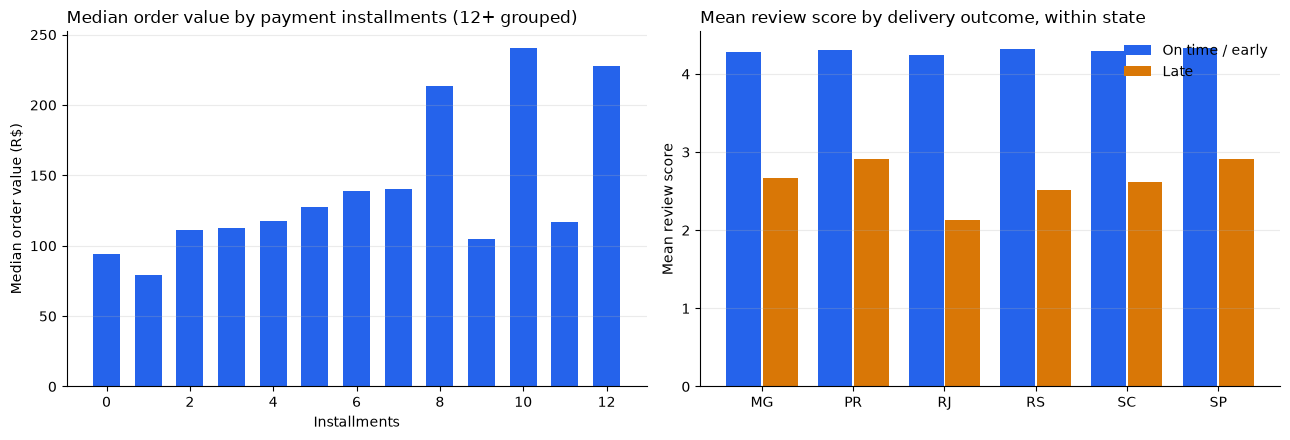

late            False  True 
customer_state              
MG               4.28   2.67
PR               4.31   2.91
RJ               4.25   2.13
RS               4.31   2.51
SC               4.29   2.62
SP               4.33   2.91

overall gap (late vs not): 1.73


In [48]:
inst = (ol[ol["max_installments"].notna()]
        .assign(inst_bucket=lambda d: d["max_installments"].clip(upper=12))
        .groupby("inst_bucket")["order_total_value"].agg(["median", "size"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(inst.index.astype(int), inst["median"], color="#2563eb", width=0.65)
axes[0].set_title("Median order value by payment installments (12+ grouped)", loc="left")
axes[0].set_xlabel("Installments"); axes[0].set_ylabel("Median order value (R$)")

# --- Does delivery -> review survive controlling for geography? ---
d = ol[ol["is_delivered_complete"] & ol["review_score"].notna()].copy()
d["late"] = d["days_early"] < 0

top_states = d["customer_state"].value_counts().head(6).index
sub = d[d["customer_state"].isin(top_states)]
pivot = sub.groupby(["customer_state", "late"])["review_score"].mean().unstack()

x = np.arange(len(pivot))
axes[1].bar(x - 0.2, pivot[False], width=0.38, label="On time / early", color="#2563eb")
axes[1].bar(x + 0.2, pivot[True],  width=0.38, label="Late",            color="#d97706")
axes[1].set_xticks(x); axes[1].set_xticklabels(pivot.index)
axes[1].set_title("Mean review score by delivery outcome, within state", loc="left")
axes[1].set_ylabel("Mean review score"); axes[1].legend(frameon=False)

for ax in axes:
    ax.grid(alpha=0.25, axis="y"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

print(pivot.round(2))
print("\noverall gap (late vs not):",
      round(d.loc[~d["late"], "review_score"].mean() - d.loc[d["late"], "review_score"].mean(), 2))


The right-hand panel is the methodological: "check whether a relationship survives controlling for geography — many apparent effects here are state effects in disguise." If the late-vs-on-time review gap persists within every state, the delivery effect is real and not a proxy for São Paulo having both faster delivery and different customers. If it collapses inside states, you'd have found a confound.

### Observations — relationships and correlation

**Delivery timing is the only variable that meaningfully moves review scores.**
Across delivered orders, `delivery_days` correlates with `review_score` at **r = −0.33**
and `days_early` at **r = +0.27** — the strongest relationships in the order-level
correlation matrix. Every monetary variable is essentially unrelated to satisfaction:
`order_item_value` (−0.03), `order_total_value` (−0.04), `order_freight_value` (−0.09).
Customers do not rate orders on what they paid; they rate them on when the parcel arrived.
Median delivery time falls monotonically with score — 16 days for 1-star orders, then 13,
12, 10, and 9 days for 5-star.

**The relationship is a threshold, not a gradient.** Binning orders by how far delivery
landed relative to the promised date shows a sharp discontinuity rather than a smooth
slope:

| Delivery outcome | Mean review score |
|---|---|
| 15+ days early | 4.31 |
| 7–15 days early | 4.31 |
| 3–7 days early | 4.25 |
| 0–3 days early | 4.13 |
| **0–3 days late** | **4.02** |
| **3–7 days late** | **2.68** |
| 7–15 days late | 1.75 |
| 15–30 days late | 1.63 |
| 30+ days late | 1.95 |

Missing the promised date by up to three days costs almost nothing (4.02 versus 4.13 for
a marginally early delivery). Beyond three days, mean scores collapse by more than a full
point and keep falling. In the other direction, early delivery shows clear diminishing
returns: arriving 15+ days early scores identically to arriving 7–15 days early.

**This asymmetry has a direct operational reading.** The objective implied by the data is
not "deliver as fast as possible" but "do not miss the quoted date by more than roughly
three days." Equally, padding the delivery estimate beyond about a week of buffer buys no
measurable satisfaction gain while making the quote less competitive. A symmetric error
metric such as RMSE or MAE, which prices a 3-day overrun the same as a 3-day underrun,
would not capture either effect.

*Caveat:* the 30+ days late bucket (1.95) scores slightly higher than the 15–30 day bucket
(1.63), breaking the monotonic pattern. This may reflect small sample size in the extreme
tail, or service recovery on severely delayed orders. It is noted rather than explained;
the bucket sizes should be checked before the figure is relied upon.

**The delivery effect survives controlling for geography.** Because São Paulo dominates
this dataset and also enjoys faster delivery, an apparent delivery effect could be a state
effect in disguise. Comparing mean review scores for late versus on-time orders *within*
each of the six largest states shows the gap persisting in every one — on-time orders
average roughly 4.25–4.35 while late orders average roughly 2.1–2.9. The effect is
therefore a property of delivery performance, not of customer location.

**Freight burden, by contrast, is strongly geographic.** Median freight as a share of
order value ranges from **32% in Roraima (RR)** down to **15.7% in São Paulo (SP)** — a
two-fold spread. Remote northern and north-eastern states carry roughly double the
shipping burden of the south-east. Item price and freight are positively but loosely
related at the item level (**r = 0.41**), consistent with freight being driven mainly by
distance and weight rather than by product value.

**Payment installments rise with order value**, as expected: median order value climbs
from ~R$95 for single-payment orders to ~R$240 at ten installments. The relationship is
noisy at 9 and 11 installments, which are uncommon choices and likely thinly populated.

**Two cautions for Phase 2.** First, `order_item_value`, `order_total_value`, and
`payment_total` are mutually correlated at r = 1.00 — they measure the same quantity three
ways, and using them together as model features would be redundant. Second,
`estimated_delivery_days` correlates with `days_early` at r = +0.50 by construction: a
longer quote mechanically creates more room to arrive "early." `days_early` therefore
partly measures how padded the original promise was, not purely how well the delivery
performed.

**All relationships reported here are associations, not causal effects.** Delivery delay
and review score move together, and the within-state check rules out the most obvious
confound, but this analysis does not establish that delay *causes* dissatisfaction — order
type, seller behaviour, and product category may all contribute and are not controlled for.


In [49]:
seller_orders = (item_level[["seller_id", "order_id"]].drop_duplicates()
                 .merge(ol[["order_id", "delivery_days", "late_delivery_flag",
                            "review_score", "is_delivered_complete"]], on="order_id")
                 .query("is_delivered_complete"))

sp = (seller_orders.groupby("seller_id")
      .agg(orders=("order_id", "size"),
           median_delivery=("delivery_days", "median"),
           late_rate=("late_delivery_flag", "mean"),
           mean_review=("review_score", "mean"))
      .query("orders >= 50"))
sp["late_rate"] *= 100
print(f"sellers with >= 50 delivered orders: {len(sp):,} of {seller_orders['seller_id'].nunique():,}")


sellers with >= 50 delivered orders: 425 of 2,970


## 8. Candidate Problem Exploration

Preliminary assessment of candidate analytics problems, to inform Phase 2 scoping. The
purpose is to narrow the field with evidence, not to commit to one.

Seven candidates are considered. Three were named at the framing stage before any data was
examined (delivery duration, low review scores, freight cost); three emerged from the
exploration in Sections 5-7 (seller reliability, quote calibration, order fulfilment
failure); and one — customer retention / lifetime value — is rejected outright on the
evidence of the 3.12% repeat rate established in Section 6.

Each is assessed against the same checklist: what decision it supports, the unit of analysis,
whether a clean target exists, data availability, leakage risk, feasibility, and what would
cause us to drop it.

The figures below are gathered in one place so each assessment cites measured evidence
rather than impressions formed earlier in the notebook.


In [50]:
d = ol[ol["is_delivered_complete"]]
r = d[d["review_score"].notna()]

print("=== C1: delivery duration @ checkout ===")
print(f"  rows {len(d):,} | median {d['delivery_days'].median():.0f}d | incumbent quote {d['estimated_delivery_days'].median():.0f}d")
print(f"  incumbent MAE {d['days_early'].abs().mean():.1f}d | bias {d['days_early'].mean():+.1f}d")

print("\n=== C2: review_score <= 2 @ post-delivery ===")
print(f"  rows {len(r):,} | base rate {(r['review_score'] <= 2).mean():.2%} | n_positive {(r['review_score'] <= 2).sum():,}")

print("\n=== C3: freight @ checkout ===")
print(f"  items {len(item_level):,} | zero-freight {(item_level['freight_value'] == 0).mean():.2%}")

print("\n=== C4: seller reliability ===")
print(f"  sellers >= 50 orders: {len(sp):,} of {seller_orders['seller_id'].nunique():,} ({len(sp)/seller_orders['seller_id'].nunique():.1%})")
print(f"  seller late rate spread: {sp['late_rate'].min():.1f}% - {sp['late_rate'].max():.1f}%")

print("\n=== C6: fulfilment failure ===")
print(f"  no-item orders {ol['item_count'].isna().sum():,} | unavailable {(ol['order_status']=='unavailable').sum():,} | canceled {(ol['order_status']=='canceled').sum():,}")



=== C1: delivery duration @ checkout ===
  rows 96,470 | median 10d | incumbent quote 23d
  incumbent MAE 12.5d | bias +10.9d

=== C2: review_score <= 2 @ post-delivery ===
  rows 95,824 | base rate 12.81% | n_positive 12,272

=== C3: freight @ checkout ===
  items 112,650 | zero-freight 0.34%

=== C4: seller reliability ===
  sellers >= 50 orders: 425 of 2,970 (14.3%)
  seller late rate spread: 0.0% - 30.1%

=== C6: fulfilment failure ===
  no-item orders 775 | unavailable 609 | canceled 625


**Reading the evidence.**

**C1 — the incumbent is beatable, and predictably so.** Olist's quote carries a mean
absolute error of **12.5 days** against a median actual delivery of 10 days: the quote is
typically wrong by more than the delivery itself takes. Critically, the bias is **+10.9
days** — almost the entire error (about 87%) is *systematic over-quoting* rather than random
variance. This means much of the improvement is available from correcting a constant
offset, before any modelling of individual orders. It also raises a question the data cannot
answer: whether the padding is an error or a deliberate under-promise strategy. Either way,
a clear numerical bar exists to beat.

**C2 — the base rate is 12.81%, not the 14.7% seen across all reviews.** Restricting to
delivered orders removes undelivered and cancelled orders, which attract disproportionately
poor scores. 12,272 positive cases across 95,824 orders is ample for modelling, but the
imbalance confirms that accuracy is the wrong metric — predicting "never a bad review"
scores 87.2% while flagging nothing.

**C3 — freight is not zero-inflated.** Only **0.34%** of items ship free. The framing stage
anticipated a zero-inflated target requiring a two-stage model; the data does not support
that characterisation, and the modelling problem is simpler than expected. This removes a
stated risk but does not address C3's real weakness, which is the absence of a decision it
would support.

**C4 — only 14.3% of sellers can be assessed.** 425 of 2,970 sellers with delivered orders
have the 50+ orders needed for a stable per-seller rate. Among those, late rates span 0.0%
to 30.1% — real and substantial variation. But given that 93% of late-delivery time occurs
in carrier transit rather than seller handling, much of that spread likely reflects seller
*location* rather than seller performance, and would need a within-region comparison to
interpret.

**C6 — the failure population is small.** 775 orders have no line items; 609 are
`unavailable` and 625 `canceled`, together about 1.4% of all orders. Enough to model, but
the data records that an order failed, not why.


### Candidate problem assessment

Seven candidates were considered: three carried from the framing stage, three that emerged
from the exploration, and one rejected outright. Each is assessed against a fixed checklist.

#### C1 — Delivery duration, predicted at checkout  ★ strongest

| Criterion | Assessment |
|---|---|
| Decision | How many days to quote at checkout. Platform operations act on it, on every order. |
| Grain | One row per delivered order; 96,470 available. |
| Target | `delivery_days` — continuous, right-skewed (median 10, mean 12.1). |
| Data | Strong. Key predictors — customer state, seller state, same-state flag, product weight, freight — are all populated and all known at purchase. |
| Leakage | Well understood and containable: every field derived from the actual delivery or carrier date is banned (`days_early`, `transit_days`, `handling_days`, `order_delivered_*`). |
| Feasibility | High. Standard regression on a clean, validated table. |
| Rejection grounds | Failure to beat the incumbent quote's MAE. |

The exploration strengthened this candidate in three ways. First, the incumbent is not just
imprecise but **biased** — quotes run ~10.9 days longer than actual delivery. Second, the
mechanism is now known: distance dominates (same-state 6 days vs cross-state 12), and 93%
of late-order delay occurs in carrier transit rather than seller handling — so the useful
predictors are geographic and available at checkout. Third, Section 7's threshold effect
means the objective is asymmetric: satisfaction collapses past ~3 days late but gains
nothing past ~7 days early. That argues for predicting an **interval under quantile loss**
rather than a point estimate, which is both more useful and more interesting than a
standard regression.

#### C2 — Predicting low review scores (1-2 stars)  ★ strong second

| Criterion | Assessment |
|---|---|
| Decision | Which delivered orders to flag for service follow-up before the review request goes out, against a fixed daily contact budget. |
| Grain | Delivered orders with a review. |
| Target | `review_score <= 2`, binary. Base rate ~12.81%. |
| Data | Good. 768 orders lack a review and are excluded. Review *text* is largely missing and in Portuguese — treat text analysis as out of scope. |
| Leakage | Materially easier than C1: prediction happens after delivery, so `delivery_days` and `days_early` are legitimate features here — the same fields banned in C1. |
| Feasibility | High, given text is excluded. |
| Rejection grounds | If delivery timing explains nearly all the variance, this collapses into C1. |

Because the class is rare, accuracy is unusable — "never a bad review" scores ~85% and
flags nothing. PR-AUC and precision@k against the base rate are the appropriate metrics.
The genuine analytical value is the **residual**: which orders score poorly *despite*
arriving on time. Shares most of C1's feature engineering, so it is cheap to pursue
alongside.

#### C3 — Freight cost prediction

Statistically tractable — no missing values, strong geographic signal, zero leakage risk —
but weak on the criterion that matters most: **no clear decision or decision-maker.**
Freight is a price the seller sets, so predicting it supports no action. Deprioritised on
business grounds, not statistical ones.

#### C4 — Seller reliability and concentration  ↓ weakened by the evidence

This looked promising after the Lorenz curve (top 10% of sellers = ~67.5% of GMV) but the
lifecycle decomposition undercut it. If 93% of late-delivery time is carrier transit and
only ~7% is seller handling, then most of what a seller-level late rate measures is
**where that seller is located**, not how well they operate. Any seller ranking would need
a within-region comparison to be meaningful. Compounding this, only 425 of ~3,000 sellers
have the 50+ orders needed for a stable per-seller rate, so 86% of the marketplace cannot
be assessed at all. Retained as descriptive context, not as a modelling problem.

#### C5 — Quote calibration (a reframing of C1)

Rather than predicting delivery duration, ask directly: **how much buffer should the quote
carry?** Section 7 gives the loss function empirically — nothing is gained beyond ~7 days
of buffer, and the penalty begins sharply past ~3 days late. This is arguably the sharper
statement of the same problem and the one closest to the actual business decision. It is
folded into C1 rather than treated separately.

#### C6 — Order fulfilment failure

775 orders contain no line items, and 609 `unavailable` plus 625 `canceled` orders never
completed. Predicting which orders fail to materialise is a legitimate binary problem with
an operational use. Not pursued here because the failure population is small (~1.4% of
orders) and the causes are not observable in this data — we can see *that* an order became
unavailable, not *why*.

#### Explicitly rejected — customer retention / CLV

The repeat rate is **3.12%**: 93,099 of 96,096 customers purchased exactly once. CLV
requires a lifetime to measure; where 96.9% of customers have a single order, CLV collapses
to that order's value, which is already fully observed. This is a structural property of
the data, not a scoping constraint, and no amount of Phase 2 time would change it.

#### Conclusion

**C1 is the strongest candidate**, with C2 a close and complementary second. C1 supports a
concrete recurring decision, has ~96,000 clean rows, a well-understood leakage boundary, an
identified causal mechanism (distance and transit), and — decisively — a **measurable
incumbent to beat**, which makes success a number rather than a judgement.

The evidence that would settle the choice is a single baseline: whether a model using only
checkout-available features beats the incumbent quote's MAE. If it does, C1 proceeds and C2
becomes a natural extension. If it does not, C2 becomes the primary problem, since its
prediction point permits the delivery features that C1 must exclude.


## 9. Key Insights and Patterns

Five findings, each traceable to a specific measurement in this notebook.

| # | Finding | Supporting evidence | Why it matters |
|---|---|---|---|
| 1 | **Olist's delivery quote is systematically padded, not merely inaccurate.** Orders arrive a median of 12 days earlier than promised. | §7. Median actual delivery 10 days vs median quote 23 days. Incumbent MAE 12.5 days with a bias of +10.9 days — roughly 87% of the error is systematic over-quoting, not variance. | A quote wrong by more than the delivery takes is a competitive liability at checkout. Because the error is systematic, much of it is correctable by adjusting a constant offset before any per-order modelling. |
| 2 | **Customer satisfaction has a cliff at roughly three days late, and no upside from arriving early.** | §7. Mean review score is 4.02 for orders 0-3 days late but falls to 2.68 at 3-7 days late and ~1.7 beyond. Arriving 15+ days early (4.31) scores the same as 7-15 days early (4.31). | The operational goal is not "deliver faster" but "do not miss the promise by more than ~3 days." It also means buffer beyond about a week is wasted. A symmetric error metric would hide both effects. |
| 3 | **Late delivery is a distance and transit problem, not a seller problem.** | §7. Decomposing the order lifecycle: late orders take ~18 extra days, of which 17.0 (93%) occur in carrier transit and only 1.3 in seller handling. Same-state orders deliver in a median of 6 days versus 12 for cross-state, with late rates of 6.06% vs 9.27%. | Identifies where intervention would work, and confirms the strongest predictors (customer state, seller state, same-state flag) are all known at checkout and carry no leakage risk. |
| 4 | **Repeat purchasing is negligible: 3.12%.** | §6. 93,099 of 96,096 customers (96.9%) placed exactly one order across the 25-month window. | Rules out retention and customer-lifetime-value analysis structurally rather than by choice. It also demonstrates a data trap: `customer_id` is issued per order, so counting customers with it yields exactly 99,441 "customers" and a 0% repeat rate — an artifact, not a finding. |
| 5 | **Growth came entirely from acquiring more customers, not from larger baskets — and average order value actually declined.** | §5. Indexed to January 2017 = 100, monthly order count reaches ~815 by August 2018 (an 8x increase, peaking at ~945 in November 2017), while average order value ends at ~90 — roughly 10% *below* its starting point, holding in a narrow R$148-175 band throughout. | Any revenue growth in this period is an acquisition story, not a basket-size story. It also means the two levers behave independently: volume scaled 8x without dragging order value up with it, and the 2018 plateau suggests the acquisition-driven phase had already ended by the time data collection stopped. |


### What the data shows versus what it suggests

**Shown.** All five findings above are direct measurements: the delivery gap, the review
score distribution across delay buckets, the lifecycle stage decomposition, the repeat rate,
and the GMV concentration are counts and medians computed from the source tables, and each
reconciles against the row counts reported in Section 2.

**Suggested, not shown.** That delay *causes* dissatisfaction is an association, not a
demonstrated causal effect. The relationship survives controlling for customer state — the
late-versus-on-time review gap persists within all six largest states — which rules out the
most obvious confound, but product category, seller behaviour, and order composition are not
controlled for. Similarly, the systematic padding of delivery quotes is consistent with a
deliberate under-promise strategy, but nothing in this data distinguishes intent from
estimation error.

**Not addressable with this data.** Why orders become `unavailable` or `canceled`, whether
the 2018 volume plateau reflects saturation or capacity, and any question requiring repeat
customer behaviour.


In [51]:
order_level.to_csv(DATA_DIR / "order_level.csv", index=False)
item_level.to_csv(DATA_DIR / "item_level.csv", index=False)
products_clean.to_csv(DATA_DIR / "products_clean.csv", index=False)
reviews_dedup.to_csv(DATA_DIR / "reviews_dedup.csv", index=False)